#MAPEO DE SERIES DE TIEMPO DE ANOMALÍAS DE ENOS Y CAUDAL

##DEFINICIONES

In [1]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt


# ============================================================
# Mapeo global de permutaciones (predefinido para w=4)
# ============================================================

# Generar todas las permutaciones posibles de (1,2,3,4)
w_fijo = 4
permutaciones = list(itertools.permutations(range(1, w_fijo+1)))
permutaciones.sort()  # Orden lexicográfico para consistencia

# Crear mapeos globales
MAQUINA_ESTADOS = {perm: idx for idx, perm in enumerate(permutaciones)}  # perm -> índice 0-23
INDICE_A_PERM = {idx: perm for idx, perm in enumerate(permutaciones)}  # índice -> perm
NUM_NODOS_GLOBAL = len(permutaciones)  # 24

# ============================================================
# 1. Crear nodos (ordinal patterns) - MODIFICADA
# ============================================================

def crear_ind(x, tamaño_w):
    """
    Devuelve la lista de patrones ordinales mapeados a índices globales.
    Usa el mapeo MAQUINA_ESTADOS para garantizar consistencia.
    """
    x = np.asarray(x)
    N = len(x)
    w = int(tamaño_w)
    if N < w:
        return []

    ind_x1 = []
    for i in range(0, N - w + 1):
        sub = x[i:i+w]

        # Orden de índices de mayor a menor (Small 2013 define orden por "pi_j-th largest")
        order_desc = np.argsort(sub, kind='stable')[::-1]  # índices del mayor al menor

        # Construir ranking: ranks[pos] = 1..w (1 = mayor)
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)

        pat = tuple(ranks.tolist())
        # Mapear a índice global usando MAQUINA_ESTADOS
        idx = MAQUINA_ESTADOS[pat]
        ind_x1.append(idx)

    return ind_x1

# ============================================================
# 2. Crear grafo (ahora PESADO) - MODIFICADA
# ============================================================

def crear_grafo(ind_x1, tamaño_w):
    """
    Construye un grafo NO dirigido y PESADO con 24 nodos fijos.
    La matriz de adyacencia siempre es de 24×24.
    """
    # Crear grafo con todos los nodos posibles (0-23)
    G = nx.Graph()
    for i in range(NUM_NODOS_GLOBAL):
        G.add_node(i)

    # Inicializar diccionario de etiquetas
    nodo_a_sublista = INDICE_A_PERM.copy()  # copia del mapeo global

    # Añadir aristas incrementando peso (transiciones cada w pasos)
    w = int(tamaño_w)
    for i in range(len(ind_x1) - w):
        a = ind_x1[i]  # ya es índice global
        b = ind_x1[i + w]  # ya es índice global
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # unique_nodes es el mapeo inverso para compatibilidad
    unique_nodes = {perm: idx for idx, perm in INDICE_A_PERM.items()}

    return G, unique_nodes, nodo_a_sublista

# ============================================================
# 3. Calcular entropía usando matriz de conectividad PESADA - MODIFICADA
# ============================================================

def calcular_entropia(unique_nodes, ind_x1, w):
    """
    Calcula entropía con matriz de adyacencia de 24×24.
    """
    # Inicializar matriz 24×24 (no usa unique_nodes para el tamaño)
    matriz_conectividad = np.zeros((NUM_NODOS_GLOBAL, NUM_NODOS_GLOBAL), dtype=int)

    w_int = int(w)
    # Rellenar matriz con conteos de transiciones
    for i in range(len(ind_x1) - w_int):
        a = ind_x1[i]  # índice global
        b = ind_x1[i + w_int]  # índice global
        matriz_conectividad[a, b] += 1
        matriz_conectividad[b, a] += 1  # red no dirigida

    # sumas por fila = fuerza (grado ponderado)
    sum_m = matriz_conectividad.sum(axis=1)

    mu = []
    for i in range(NUM_NODOS_GLOBAL):
        if sum_m[i] == 0:
            mu.append(0.0)
            continue
        ent = 0.0
        for j in range(NUM_NODOS_GLOBAL):
            if matriz_conectividad[i, j] > 0:
                p = matriz_conectividad[i, j] / sum_m[i]
                ent -= p * np.log2(p)
        mu.append(ent)

    mut = float(np.mean(mu)) if NUM_NODOS_GLOBAL > 0 else 0.0

    return mu, mut, matriz_conectividad




In [2]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extraer patrones ordinales (para cualquier w)
# ------------------------------------------------------------
def obtener_patrones(x, w):
    """
    Devuelve una lista de tuplas, cada una es el patrón ordinal (permutación)
    de una ventana deslizante de longitud w sobre la serie x.
    El orden es de mayor a menor, con desempate estable (primero aparece = más pequeño).
    """
    x = np.asarray(x)
    N = len(x)
    if N < w:
        return []
    patrones = []
    for i in range(N - w + 1):
        sub = x[i:i+w]
        # Índices ordenados de mayor a menor (argsort descendente estable)
        order_desc = np.argsort(sub, kind='stable')[::-1]
        # Asignar rangos: 1 al más grande, w al más pequeño
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)
        patrones.append(tuple(ranks))
    return patrones

# ------------------------------------------------------------
# 2. Construir grafo a partir de la lista de patrones
# ------------------------------------------------------------
def construir_grafo(patrones, w):
    """
    Construye un grafo no dirigido y pesado.
    - Nodos: patrones ordinales distintos que aparecen en la serie.
    - Aristas: entre patrones que ocurren en tiempos sucesivos no solapados
               (separados por w pasos). El peso acumula el número de transiciones.
    """
    # Mapear cada patrón único a un índice local
    unique_pat = {}
    for p in patrones:
        if p not in unique_pat:
            unique_pat[p] = len(unique_pat)
    num_nodes = len(unique_pat)

    # Crear grafo con todos los nodos (inicialmente aislados)
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    # Añadir aristas con peso (transiciones cada w pasos, sin solapamiento)
    for i in range(len(patrones) - w):
        a = unique_pat[patrones[i]]
        b = unique_pat[patrones[i + w]]
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # También devolvemos el mapeo inverso (índice -> patrón) por si se necesita
    idx_to_pat = {v: k for k, v in unique_pat.items()}
    return G, idx_to_pat

# ------------------------------------------------------------
# 3. Calcular entropía de la red (promedio de entropías nodales)
# ------------------------------------------------------------
def calcular_entropia_red(G):
    """
    Calcula la entropía nodal promedio para un grafo pesado no dirigido.
    Para cada nodo i: μ(i) = - Σ_j p(i,j) log2 p(i,j), con p(i,j) = peso(i,j) / fuerza(i).
    La entropía total es el promedio sobre todos los nodos.
    Los nodos aislados contribuyen con 0.
    """
    entropias = []
    for node in G.nodes():
        # Obtener pesos de las aristas incidentes
        weights = [G[node][nbr]['weight'] for nbr in G.neighbors(node)]
        strength = sum(weights)
        if strength == 0:
            entropias.append(0.0)
            continue
        # Calcular entropía
        ent = 0.0
        for wgt in weights:
            p = wgt / strength
            ent -= p * np.log2(p)
        entropias.append(ent)
    return np.mean(entropias) if entropias else 0.0

# ------------------------------------------------------------
# 4. Función de optimización de w (adaptada)
# ------------------------------------------------------------
def optimizar_w(x, w_min, w_max):
    """
    Encuentra el valor óptimo de w que maximiza la entropía promedio de la red.

    Parámetros:
        x (list): Serie temporal.
        w_min (int): Valor mínimo de w (inclusive).
        w_max (int): Valor máximo de w (exclusive, como en range).

    Retorna:
        w_optimo (int): w que maximiza la entropía.
    """
    valores_w = range(w_min, w_max)
    entropias = []

    for w in valores_w:
        # 1. Obtener patrones ordinales
        patrones = obtener_patrones(x, w)
        if len(patrones) < w + 1:   # se necesitan al menos dos transiciones
            entropias.append(0.0)
            continue

        # 2. Construir grafo
        G, _ = construir_grafo(patrones, w)

        # 3. Calcular entropía promedio
        ent = calcular_entropia_red(G)
        entropias.append(ent)

    # Encontrar w óptimo
    idx_opt = np.argmax(entropias)
    w_optimo = valores_w[idx_opt]

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(valores_w, entropias, marker='o', linestyle='-', color='black')
    plt.axvline(x=w_optimo, color='r', linestyle='--',
                label=f'$w_{{opt}}$ = {w_optimo}')
    plt.xlabel('Tamaño de ventana w')
    plt.ylabel('Entropía promedio de la red')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    return w_optimo


In [3]:
# Después de crear el grafo:
def contar_nodos_activos(G):
    """
    Cuenta cuántos nodos de los 24 tienen al menos una conexión.
    """
    nodos_activos = 0
    for nodo in G.nodes():
        if G.degree(nodo, weight='weight') > 0:
            nodos_activos += 1
    return nodos_activos

#MAPEO NIÑO 3.4

len() de nodos es 832
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24
El grado medio de la red es: 14.5
La distancia minima promedio de la red es: 1.394927536231884
la distancia maxima es: 2
[[37. 21.  8.  5.  1.  3. 15.  1.  3.  6.  1. 11. 10.  2.  4.  3.  3. 14.
   5.  0.  8. 16. 24. 66.]
 [21.  3.  3.  4.  1.  4.  7.  2.  2.  2.  1.  2.  3.  0.  1.  1.  2. 11.
   1.  0.  1.  2.  7. 20.]
 [ 8.  3.  0.  3.  0.  0.  3.  0.  1.  0.  0.  4.  1.  0.  0.  0.  0.  1.
   1.  0.  3.  0.  3.  9.]
 [ 5.  4.  3.  0.  1.  0.  3.  1.  0.  0.  0.  1.  4.  1.  2.  1.  1.  6.
   0.  0.  1.  4.  3.  7.]
 [

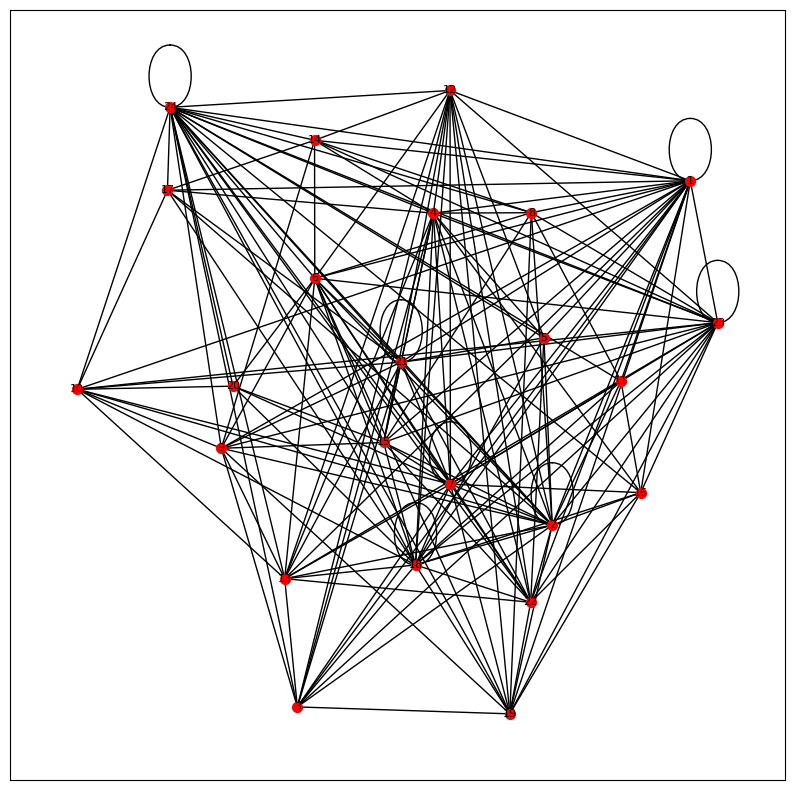

In [4]:

w_opt=4
x =[
-1.99, -1.69, -1.42, -1.54, -1.75, -1.27, -1.01, -0.97, -0.98, -1.03, -1.23, -1.31, -1.30, -1.04, -0.38, -0.23, -0.01, 0.00, 0.30, 0.17, 0.51, 0.49, 0.55, 0.31, 0.13, -0.01, -0.11, -0.02, -0.14, -0.54, -0.76, -0.56, -0.36, -0.46, -0.78, -0.39, 0.20, 0.24, 0.29, 0.22, 0.35, 0.39, 0.14, 0.09, 0.29, 0.16, 0.18, 0.41, 0.43, 0.28, -0.38, -1.17, -0.81, -0.93, -1.18, -1.43, -1.60, -1.48, -1.13, -1.33, -0.93, -0.95, -1.06, -1.22, -1.28, -1.18, -1.15, -1.35, -1.43, -2.31, -2.45, -2.03, -1.20, -0.99, -0.83, -0.97, -0.80, -0.92, -1.06, -1.17, -0.98, -0.97, -1.14, -0.89, -0.51, -0.22, 0.18, 0.41, 0.62, 0.63, 0.87, 0.84, 0.72, 0.70, 0.92, 1.30, 1.78, 1.49, 0.98, 0.46, 0.38, 0.26, 0.03, -0.01, -0.32, -0.27, 0.05, 0.02, 0.53, 0.43, 0.19, 0.06, -0.23, -0.35, -0.86, -0.77, -0.80, -0.48, -0.66, -0.42, -0.28, -0.46, -0.30, -0.33, -0.25, -0.49, -0.41, -0.15, -0.28, -0.49, -0.45, -0.38, -0.31, -0.19, -0.35, -0.46, -0.18, -0.06, -0.41, -0.67, -0.94, -1.01, -0.63, -0.63, -0.59, -0.57, -0.48, -0.69, -0.89, -0.65, -0.53, -0.53, -0.78, -0.75, -0.95, -0.93, -0.78, -0.53, -0.10, -0.03, -0.30, -0.11, 0.49, 0.62, 0.68, 0.64, 0.77, 1.02, 0.79, 0.38, -0.26, -0.87, -1.12, -1.14, -0.96, -1.26, -1.40, -1.35, -1.44, -1.37, -0.89, -0.56, -0.34, -0.44, 0.06, 0.36, 0.61, 1.12, 1.29, 1.45, 1.42, 1.36, 1.12, 0.80, 0.93, 0.35, -0.38, -0.08, 0.04, -0.37, -0.44, -0.50, -0.47, -0.57, -0.67, -0.64, -0.78, -1.08, -0.59, -0.26, -0.33, -0.42, -0.86, -0.74, -0.62, -0.65, -0.85, -1.07, -0.95, -0.72, -0.75, 0.15, 0.28, 0.16, 0.01, 0.04, 0.50, 0.67, 0.95, 1.11, 0.54, 0.31, 0.35, -0.04, -0.21, 0.16, 0.43, 0.62, 0.40, 0.38, 0.28, 0.20, -0.14, -0.08, -0.30, -0.69, -1.08, -1.26, -1.07, -1.12, -1.13, -1.33, -1.73, -1.57, -1.36, -1.18, -0.98, -1.13, -1.17, -1.10, -1.00, -1.24, -1.15, -1.23, -0.92, -0.45, -0.19, 0.07, 0.38, 0.45, 0.85, 1.09, 1.23, 1.54, 1.90, 2.09, 1.80, 1.20, 0.27, -0.58, -0.97, -1.18, -1.54, -1.63, -1.66, -1.98, -2.37, -2.26, -2.09, -1.66, -1.45, -1.36, -1.29, -1.20, -0.90, -0.52, -0.64, -0.94, -1.09, -0.97, -0.45, -0.68, -1.09, -0.96, -1.13, -1.50, -1.39, -1.52, -1.66, -1.83, -1.66, -1.93, -2.01, -1.26, -0.82, -0.93, -0.74, -0.38, -0.16, 0.12, 0.30, 0.75, 0.71, 0.49, 0.78, 0.37, 0.19, -0.38, -0.21, 0.01, 0.09, -0.01, 0.40, 0.63, 0.48, 0.70, 0.62, 0.25, -0.20, -0.70, -0.74, -0.71, -0.55, -0.79, -0.71, -0.46, -0.38, -0.06, -0.13, -0.22, -0.02, 0.02, -0.25, -0.29, -0.47, -0.10, 0.28, 0.11, 0.29, 0.52, 0.54, 0.22, 0.03, -0.07, 0.08, 0.21, -0.06, -0.38, -0.28, -0.26, -0.10, 0.05, -0.36, -0.64, -0.64, -0.53, -0.57, -0.46, -0.64, -0.53, -0.19, -0.30, -0.41, -0.20, 0.13, -0.17, 0.13, 0.21, 0.45, 0.53, 0.37, 0.73, 1.49, 1.99, 1.92, 2.20, 2.35, 1.94, 1.38, 0.95, 0.90, 0.54, -0.11, -0.27, -0.52, -1.16, -1.29, -1.03, -0.67, -0.19, -0.52, -0.68, -0.73, -0.90, -0.50, -0.24, -0.34, -0.67, -1.19, -1.34, -1.16, -0.72, -0.79, -1.18, -1.03, -0.91, -0.74, -0.56, -0.70, -0.49, -0.37, -0.41, -0.66, -0.71, -0.42, -0.33, -0.53, -0.31, -0.11, 0.32, 0.53, 0.81, 1.01, 1.12, 1.14, 1.13, 0.98, 0.58, 0.62, 0.92, 1.29, 1.57, 1.65, 1.24, 1.07, 0.94, 0.90, 0.28, 0.10, -0.44, -1.25, -1.74, -1.74, -1.19, -1.00, -1.90, -2.05, -1.96, -1.97, -1.47, -1.21, -1.08, -0.88, -0.59, -0.57, -0.53, -0.30, -0.40, -0.45, -0.13, 0.01, 0.21, 0.04, 0.08, 0.08, -0.08, 0.09, 0.22, 0.22, 0.21, 0.10, 0.35, 0.49, 0.32, 0.03, 0.19, 0.26, 0.52, 0.76, 0.68, 0.42, 0.86, 1.20, 1.69, 1.84, 1.78, 1.38, 1.20, 1.04, 0.58, 0.22, 0.05, -0.06, -0.30, -0.28, -0.15, 0.14, 0.41, 0.39, 0.59, 0.78, 0.35, 0.23, 0.13, 0.35, 0.06, 0.00, 0.16, 0.10, 0.06, 0.11, 0.26, 0.31, 0.32, 0.24, 0.53, 0.48, 0.75, 1.11, 1.25, 1.02, 0.73, 0.46, 0.28, -0.11, -0.14, -0.21, -0.63, -0.84, -0.88, -1.10, -0.95, -0.86, -0.86, -0.61, -0.47, -0.38, -0.44, -0.44, -0.22, -0.45, -0.44, -0.41, -0.64, -0.53, -0.37, -0.25, 0.16, 0.64, 1.09, 1.56, 1.89, 2.13, 2.36, 2.41, 2.29, 2.38, 2.03, 1.34, 0.78, 0.57, -0.39, -0.99, -1.28, -1.26, -1.46, -1.46, -1.69, -1.69, -1.32, -0.95, -1.11, -1.15, -1.19, -1.17, -1.22, -1.09, -1.23, -1.58, -1.74, -1.77, -1.55, -0.98, -0.87, -0.86, -0.79, -0.67, -0.49, -0.52, -0.70, -0.79, -0.92, -0.73, -0.63, -0.48, -0.49, -0.34, -0.19, -0.04, -0.05, -0.20, -0.14, -0.37, -0.41, -0.15, -0.04, 0.01, 0.02, 0.31, 0.72, 0.74, 0.87, 1.09, 1.25, 1.47, 1.37, 0.60, 0.64, 0.36, -0.14, -0.61, -0.29, 0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27, 0.23, 0.12, 0.07, 0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36, 0.45, 0.26, 0.30, 0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92, -0.91, -0.67, -0.71, -0.32, -0.09, 0.00, 0.01, 0.31, 0.60, 0.70, 0.99, 1.14, 0.70, 0.13, -0.18, -0.32, -0.47, -0.35, -0.59, -0.72, -1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99, -0.84, -0.68, -0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35, 0.06, 0.31, 0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90, 0.38, -0.22, -0.69, -1.07, -1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11, -0.93, -0.77, -0.52, -0.38, -0.43, -0.65, -0.80, -1.05, -1.19, -1.06, -0.87, -0.67, -0.61, -0.50, -0.32, 0.02, 0.25, 0.47, 0.38, 0.26, 0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39, -0.38, -0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23, -0.06, -0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70, 0.92, 1.18, 1.46, 1.93, 2.21, 2.36, 2.72, 2.66, 2.57, 2.26, 1.62, 0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74, -0.76, -0.50, -0.43, -0.08, 0.03, 0.22, 0.37, 0.34, 0.25, -0.16, -0.43, -0.56, -0.97, -0.98, -0.98, -0.78, -0.80, -0.51, -0.20, 0.04, 0.12, 0.09, 0.47, 0.90, 0.90, 0.89, 0.65, 0.71, 0.81, 0.62, 0.55, 0.45, 0.35
]

nodos = crear_ind(x , w_opt)
print("len() de nodos es",len(nodos))

G, unique_nodes, nodo_a_sublista= crear_grafo(nodos, w_opt)
A = nx.to_numpy_array(G)
print(unique_nodes)
print("len() de unique_nodes es",len(unique_nodes))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G)  # Layout para la visualización
nx.draw_networkx_nodes(G, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G, pos, edge_color="black")
# Etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G):
    grados = [grado for _, grado in G.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G)
distancia_media=nx.average_shortest_path_length(G)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G))
print(A)
plt.show()

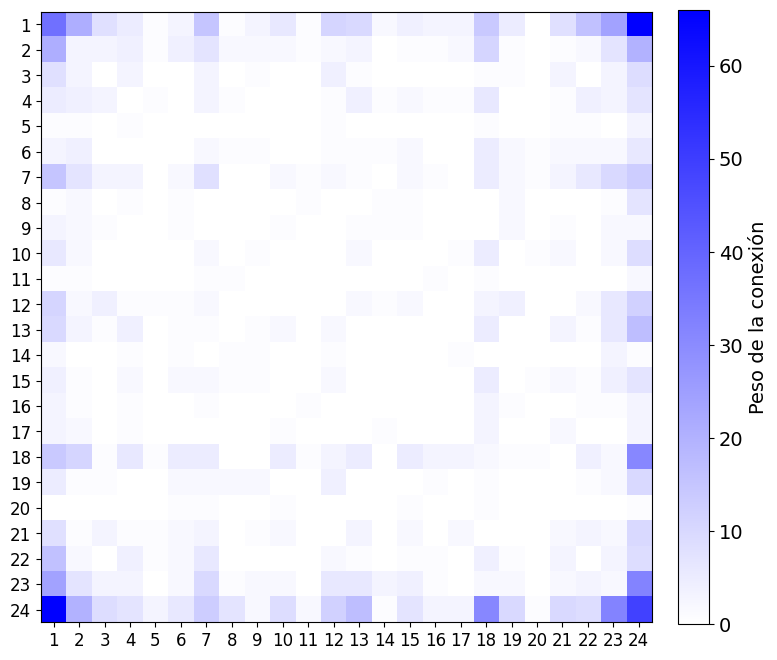

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(G).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
azul_personalizado = LinearSegmentedColormap.from_list(
    'azul_personalizado',
    [(1, 1, 1), (0, 0, 1)]  # Blanco → Azul
)

im = ax.imshow(C, cmap=azul_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.savefig("matriz_adyacencia_nino34_timbues.png", dpi=300, bbox_inches='tight')

plt.show()

In [6]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
#A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)

cmap = ListedColormap(['white', 'blue'])
#plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')

NIÑO 3.4
[[37 21  8  5  1  3 15  1  3  6  1 11 10  2  4  3  3 14  5  0  8 16 24 66]
 [21  3  3  4  1  4  7  2  2  2  1  2  3  0  1  1  2 11  1  0  1  2  7 20]
 [ 8  3  0  3  0  0  3  0  1  0  0  4  1  0  0  0  0  1  1  0  3  0  3  9]
 [ 5  4  3  0  1  0  3  1  0  0  0  1  4  1  2  1  1  6  0  0  1  4  3  7]
 [ 1  1  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0  1  0  0  1  1  0  3]
 [ 3  4  0  0  0  0  2  1  1  0  0  1  1  1  2  0  0  5  2  1  2  2  2  6]
 [15  7  3  3  0  2  8  0  0  2  1  2  1  0  2  1  0  5  2  1  3  6 10 13]
 [ 1  2  0  1  0  1  0  0  0  0  1  0  0  1  1  0  0  0  2  0  0  0  1  7]
 [ 3  2  1  0  0  1  0  0  0  1  0  0  1  1  1  0  0  0  2  0  1  0  2  2]
 [ 6  2  0  0  0  0  2  0  1  0  0  0  2  0  0  0  1  5  0  1  2  0  2  9]
 [ 1  1  0  0  0  0  1  1  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  2]
 [11  2  4  1  1  1  2  0  0  0  0  0  2  1  2  0  0  3  4  0  0  2  6 12]
 [10  3  1  4  0  1  1  0  1  2  0  2  0  0  0  0  0  5  0  0  3  1  6 17]
 [ 2  0  0  1  0

In [7]:
nodos_activos = contar_nodos_activos(G)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


#Mapeo anomalias caudal Timbues

len() de nodos es 832
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24


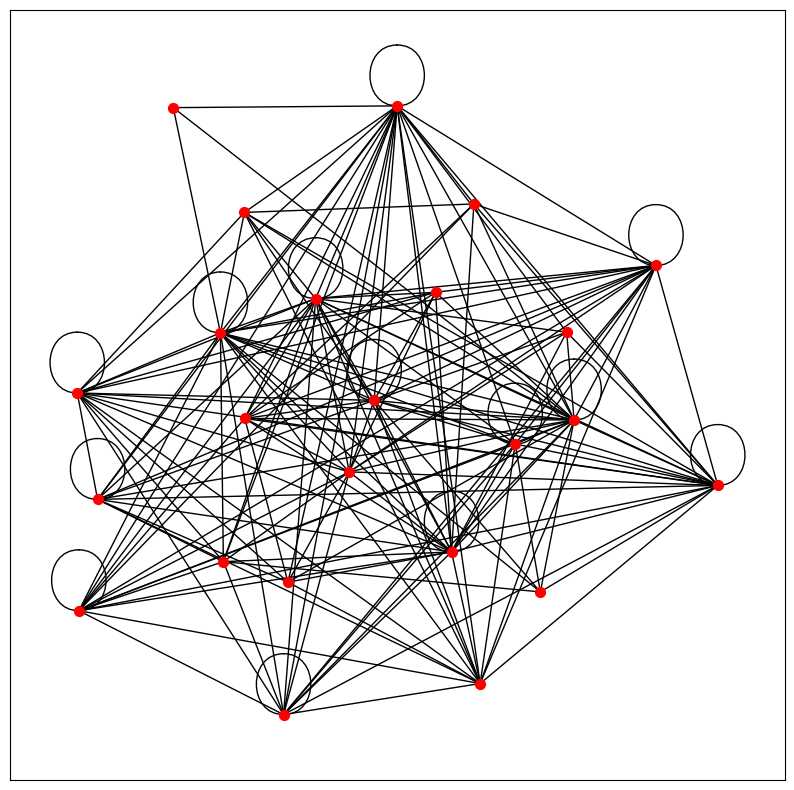

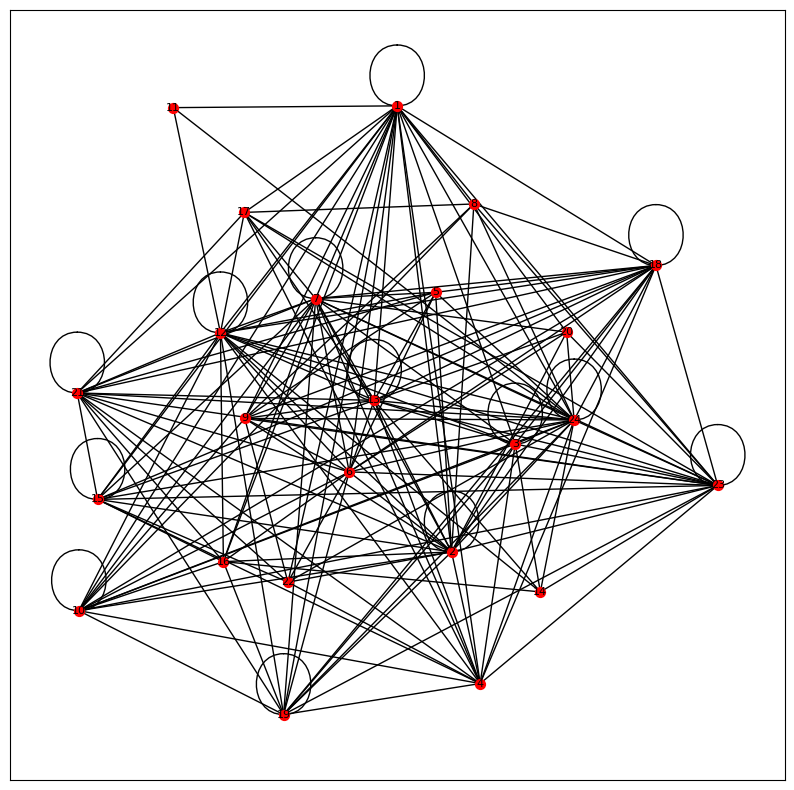

El grado medio de la red es: 14.583333333333334
La distancia minima promedio de la red es: 1.4130434782608696
la distancia maxima es: 2
[[ 8. 16.  4. 10.  0.  4. 17.  1.  3. 13.  1. 10. 12.  0.  2.  4.  1. 21.
  11.  1. 10.  6. 26. 80.]
 [16.  3.  1.  3.  2.  3.  8.  2.  1. 10.  0.  4.  5.  0.  3.  1.  0.  8.
   3.  1.  9.  2. 14. 24.]
 [ 4.  1.  1.  1.  0.  0.  1.  0.  0.  2.  0.  1.  1.  2.  0.  0.  0.  1.
   2.  0.  0.  0.  1.  7.]
 [10.  3.  1.  0.  0.  0.  4.  0.  0.  2.  0.  4.  8.  0.  5.  0.  2. 12.
   2.  0.  4.  1.  5. 10.]
 [ 0.  2.  0.  0.  0.  1.  2.  0.  1.  0.  0.  1.  2.  0.  0.  0.  0.  1.
   0.  0.  3.  0.  0.  1.]
 [ 4.  3.  0.  0.  1.  0.  1.  0.  2.  2.  0.  1.  5.  0.  0.  1.  0.  3.
   1.  1.  3.  1.  2.  9.]
 [17.  8.  1.  4.  2.  1.  2.  0.  1.  3.  0.  7.  7.  0.  2.  2.  1. 13.
   7.  3. 10.  0.  8. 19.]
 [ 1.  2.  0.  0.  0.  0.  0.  0.  1.  2.  0.  0.  0.  0.  0.  0.  1.  1.
   0.  0.  0.  0.  3.  1.]
 [ 3.  1.  0.  0.  1.  2.  1.  1.  0.  1.  0.  0.  1.  0

In [8]:

w_opt=4
x1 =[
    -1.098342295, -0.7263712684, -0.2082966367, 0.2997729425, 0.08720261098,
    -0.3923660268, -0.4109375264, -0.7184492257, -1.094889783, -0.7584700708,
    -0.6395014836, -0.6613836449, -0.4360540475, -0.1847762812, 0.5026179488,
    1.056794688, 0.3995191011, -0.9135015839, -1.418730715, -1.381957032,
    -1.40638842, -1.509720596, -1.263008861, -0.8997605967, -1.338568578,
    -1.643874879, -0.8149070459, -0.2346063144, -0.779300134, -1.07079741,
    -0.9247239273, -1.052001543, -1.033041129, -0.490250981, -0.04499216921,
    -0.6037071474, -1.321685132, -1.833954403, -2.325660457, -2.244841703,
    -1.506674608, -1.106170038, -1.133722371, -1.473854828, -1.24023863,
    -0.7301123922, 0.05570440091, 0.08188208743, -0.4317485268, -0.7748902665,
    -1.03280088, -1.382091304, -0.9788189536, 0.4197875723, 1.049484142,
    0.6928774938, -0.0797289982, -0.05958420689, -0.4423244607, -1.309291382,
    -1.474527603, -1.518698347, -2.164484139, -1.407587784, -0.8719854516,
    -0.503772707, 0.3561039155, 0.06252721278, -0.7660956893, -1.358084521,
    -1.582686154, -1.518210878, -1.120789054, -1.439613907, -1.981453937,
    -1.252945468, 0.005308961433, 0.6771674172, 0.9448294928, 1.295227293,
    1.355819624, 0.5030753814, -0.286499705, -0.9183969467, -1.146912438,
    -0.6177849486, -0.08491476645, 0.1783420141, 0.0847286846, -0.1117057158,
    0.03039654133, 0.8237091803, 1.676932576, 1.906513434, 1.22323799,
    0.3474200165, -0.3538863304, -0.5663922358, -0.2034347692, -0.1444938966,
    -0.2729074623, -0.454353627, -0.6689705299, -0.6593754737, -0.117722295,
    0.1887050491, 0.1126587536, 0.5821057687, 0.7811867857, 0.9588285337,
    1.1231018, 1.29605721, 1.2293275, 0.8055397676, 0.2611663755,
    -0.0142210246, -0.03922257632, 0.02529343815, -0.1097169242, -0.1502306461,
    0.005854432683, -0.0002971594942, 0.1565762445, -0.01151928637,
    -0.6374706031, -1.058387675, -1.003416395, -0.668022156, -0.3385035591,
    -0.1558205546, 0.3689227001, 0.1681864232, -0.01237146511, 0.3186183487,
    0.4510684584, 1.249896823, 1.795522327, 1.44757252, 0.7508211873,
    -0.0757363328, -0.4032777482, -0.2552352548, -0.1773709002, -0.1233582317,
    -0.4218192222, -0.5093456562, -0.1074026154, 0.1214696638, -0.5686553319,
    -1.139783807, -1.368763588, -1.429537604, -1.23976178, -0.5678340463,
    -0.5941904783, -0.9655649474, -0.3577927438, 0.2856040442, 0.2062494649,
    -0.2755039298, -0.7308245494, -0.9794710477, -1.160202645, -1.269157132,
    -1.281337891, -1.489022226, -0.474276257, 0.1094037682, -1.004116701,
    -1.657682076, -1.147499866, -0.9563660556, -0.7264383448, -1.074693773,
    -1.523604114, -1.421141033, -1.13323105, -1.336383146, -1.381734235,
    -1.119489175, -0.6941328691, -0.3675903673, 0.1456764717, 0.8897052716,
    1.041081761, 1.122549852, 1.257619098, 1.014924722, 0.3766416366,
    0.3834442746, 0.977857509, 1.099631197, 1.55189917, 2.056935092,
    2.488834607, 2.383228255, 1.451873894, 0.461560497, -0.3471085521,
    -0.7554179607, -0.8740698549, -0.6218399881, -0.2978243923, -0.3981301716,
    -0.2373228248, 0.1865744969, 0.3293437317, 0.5156613018, -0.5168098585,
    -1.169525641, -0.8512354094, -0.7072061567, -0.7089510903, -0.9810589594,
    -1.295499928, -1.171719049, -0.9019694335, -0.7831104273, -1.043907851,
    -1.824909805, -2.121037451, -1.934214449, -1.828783519, -1.503451254,
    -1.430256665, -1.515282713, -1.328959231, -1.304626283, -0.81004173,
    -0.7868529396, -1.772818194, -2.09457308, -1.67629235, -0.9111197943,
    -0.5632566696, -1.217038838, -1.593236051, -1.110290254, -0.2679806547,
    -0.2176942332, -0.8468079737, -1.137673365, -0.8169202699, -1.294746502,
    -1.776626781, -1.424401553, -0.9691186828, -1.114469654, -1.204603804,
    -0.5241707765, -0.879869197, -1.348379624, -0.4228835082, 0.3407660016,
    -0.2107070273, -0.8069434913, -0.5183477046, -0.2106171614, -0.107853517,
    -0.1648829121, -0.7647682437, -1.011422647, -1.273438849, -1.296101656,
    -1.215679827, -1.355086594, -0.6460564434, -0.4868034964, -1.175328944,
    -1.030111558, -0.4379704325, -0.1908586889, 0.4940496873, 1.179152658,
    1.261452681, 1.381533043, 1.27905494, 1.211167422, 1.065608505,
    0.8472876186, 0.8443176921, 0.8546657042, 0.8953919719, 0.8115728591,
    0.781667192, 0.9247411652, 0.3643266419, -0.1193303754, 0.1081226422,
    0.7670381469, 0.7000097676, 0.6063903387, 0.8340876722, 0.6251222616,
    0.5706632165, 0.4574400084, 0.4128564141, -0.3044736677, -0.7769910312,
    -0.5986212274, -0.2230552292, -0.02830203382, -0.2775494218, -0.4085789199,
    -0.2558841743, -0.3794677202, -0.7187189062, -0.348797605, 0.1197100341,
    0.5859079389, 0.5333635328, 0.5121533271, 0.6222332523, 0.4233685934,
    0.3588847123, 0.1370285392, -0.6642692435, -0.4425912509, -0.02027288793,
    0.07423477288, 0.4510688038, 0.2898001079, 0.4025413335, 0.7601730872,
    0.9070506997, 1.583119675, 1.60209846, 0.860308318, 0.2733756007,
    -0.3749484272, -0.5635560118, -0.3597310131, -0.2764358125, -0.3559265065,
    -0.346089131, 0.2346280168, 0.7029859528, 0.4036669396, 0.04260311494,
    -0.6266612958, -1.495307919, -1.276742814, -0.8392271807, -0.298227615,
    0.3361738782, -0.01037184609, -0.3122253745, -0.1598494074, -0.3632472096,
    -0.2085278679, -0.2001067867, -0.4384490927, -0.2031159932, 0.3981438231,
    0.4489230336, 0.6040048453, 1.07512288, 1.414507061, 1.527901493,
    1.49302651, 1.07806211, 0.8014157952, 1.046818414, 1.113279859,
    0.5207816115, 0.3495675302, 0.4190348631, 0.6608276014, 1.002577334,
    1.020651862, 0.8610318388, 0.6578535139, 0.7296535737, 1.292486867,
    1.054830224, 0.2908964965, 0.2359457632, 0.1166773679, -0.3265920961,
    -0.2413929488, -0.1044993905, -0.2559126087, -0.3673045354, 0.1752081189,
    0.9179838195, 1.053647755, 0.7127054046, 0.7900567689, 0.9034378463,
    0.6936933725, 1.121061475, 2.085993777, 2.420959379, 1.592038894,
    0.9872702361, 2.269873743, 3.073187163, 2.909973929, 2.899231002,
    2.53243572, 2.420208798, 2.811971512, 2.916965193, 2.797987318,
    2.412401866, 2.289557024, 2.148675747, 1.826484918, 1.489287708,
    1.494756288, 0.7190052891, -0.104944239, 0.3635869919, 0.6580276005,
    0.5903276985, 0.6176418304, 0.7441378568, 0.8400328586, 0.9572426561,
    1.054471112, 0.781436472, 0.2708278039, 0.815027281, 1.174411182,
    1.549079142, 1.471170558, 1.154841094, 1.285294327, -0.7954799215,
    1.089468406, 0.06206534539, -0.561817442, -1.049723775, -1.498063928,
    -1.051522494, 0.08993605355, 1.042713215, 1.320824672, 1.278135554,
    1.107108359, 0.8463125029, 0.7404488199, 0.6672742831, 0.3768293791,
    0.1777849988, 0.1719386007, 0.1951424945, 0.4063476543, 0.9732560606,
    1.637700399, 1.776310107, 1.537644056, 0.8232175274, -0.005408926699,
    0.2235401885, 0.47043195, 0.270680235, 0.08440391241, -0.1243712176,
    -0.2021406056, -0.1353839006, 0.6866090753, 1.035081176, 1.078095525,
    1.041176359, 0.1556449719, -0.6495882992, -0.9366846166, -0.8230550452,
    -0.05889420845, 0.5157929248, 0.5674573001, 0.4624905569, 0.2073197287,
    0.1646630453, 0.7463416213, 1.620651461, 1.998841972, 1.522913238,
    0.5476465563, 0.3044834097, 1.342422673, 0.8234190286, -0.02277616861,
    0.6376579174, 1.240552257, 1.650943277, 1.993199707, 2.333558971,
    2.087333691, 1.740601403, 0.553272357, -0.2400050692, -0.4000048639,
    -0.1365208691, 0.8340876722, 0.8104499184, 0.6069411924, 0.6810627435,
    0.08816064795, 0.1003103746, -0.1678478677, -0.06060783773, 0.5637217105,
    0.4554472698, 0.3121696985, 0.6629902294, 1.648143178, 2.829511255,
    2.722173992, 2.115387732, 2.00524982, 1.679899501, 1.715506458,
    2.07270116, 1.8454486, 1.473036351, 1.163516929, 0.8862206571,
    0.4404659258, 0.407060266, 0.2550989387, 0.1783999008, 0.1499319747,
    0.9872270558, 1.670379295, 1.035558223, 0.2084436921, 0.1905041347,
    0.3889324227, -0.2718185557, -0.3732151477, 0.2289146208, 0.8883574295,
    0.8750295023, 0.2730751058, -0.08563627718, 0.4032521905, 0.543378231,
    0.1256349846, 1.031323479, 1.722679842, 1.605858082, 0.9661685959,
    0.3744724991, 0.1402781666, 0.2890083552, 0.1587085809, 0.3501757808,
    0.4294190815, -0.1501104116, -0.5646149589, -0.126500019, 0.2007986952,
    0.4422979776, 0.5937824987, -0.007725333321, -0.2455509435, -0.2508495131,
    -0.07746074168, 0.570745634, 1.303736416, 1.28262813, 1.044984584,
    1.634766344, 1.797271623, 0.3420615357, -0.749719998, -0.2050352238,
    0.6323392294, 1.25524532, 1.220613493, 1.195422176, 1.887533851,
    2.370678361, 2.374809945, 2.163690254, 2.015631101, 2.698463978,
    3.168016567, 2.428039249, 1.48852709, 1.297168628, 1.967475616,
    2.440958631, 1.963399451, 0.8132686495, 0.1404563766, 0.3857256032,
    0.4115065527, 0.3439730547, 0.2766759522, 0.111883253, 0.6343931776,
    0.6961670443, 0.2043507995, -0.1655926861, -0.6861790502, -0.7040741122,
    -0.8815230481, -1.35576292, -1.293605146, -0.9261674972, -0.2995723769,
    -0.1076334663, -0.0853878825, 0.01000755071, 0.6645052987, 1.12916134,
    1.005144613, 0.5822825134, 0.2718884415, 0.4393491207, 0.5500588189,
    0.298783484, -0.11946385, -0.41817974, -0.5940117812, -0.4480962944,
    -0.2762695596, 0.2151465978, 0.2361726076, -0.120976386, -0.5050197804,
    -0.3305457968, 0.2265392019, 0.5785664806, 0.8714987881, 0.7885374544,
    0.5076079268, 0.4385221157, 0.7709509687, 0.9408283186, 0.9093357972,
    1.388885384, 1.223716906, 0.5587539741, 0.7986152873, 1.168875951,
    0.9069855905, 0.2228990754, -0.151678371, 0.005549626247, 0.255063087,
    0.2324086996, 0.1226291357, 0.4893857191, 0.6542924493, -0.268607219,
    -1.111190618, -1.119870478, -0.5739428481, -0.08779254852, 0.2011620739,
    0.4662724871, 0.3885744702, 0.1972344969, 0.7098068181, 1.16288898,
    0.6339396171, 0.7561555522, 0.06507815318, -0.4578553841, -0.1792847272,
    0.1527071261, 0.1679500533, 0.04103794451, 0.3402670502, 0.7897276135,
    0.9050093744, 0.5513678146, 0.1051680391, -0.4697004219, -0.6158799962,
    -0.2693621175, -0.4183529375, -0.5136296515, -0.388377484, -0.08985686511,
    0.2772417384, 0.4574634167, 0.4878797157, 0.6360958758, 0.7330205876,
    0.9896708444, 1.360503364, 1.201863635, 0.8454356394, 0.7795049755,
    0.3459320362, 0.1900955508, 0.3770553357, 0.3819371623, 0.438055994,
    0.4398755501, 0.07464359094, -0.2713927174, -0.5488848322, -0.3498524105,
    -0.03079966569, -0.09228374864, -0.140881327, 0.4694072071, 0.7117481847,
    0.4448932928, 0.7688520708, 0.1833684355, -0.5474690696, -0.667445413,
    -0.9934252321, -1.329870842, -1.262104921, -0.936563414, -0.1547028788,
    0.647060797, 1.132824232, 1.256046646, 1.487567712, 1.943557266,
    1.968921499, 1.97021841, 1.496994472, 1.05958955, 1.095649891,
    0.8622251379, 0.4599503409, 0.5206298669, 0.5094983185, 0.3722314635,
    0.08863423837, 0.3471783451, 0.5006228541, 0.3513880533, 0.595763112,
    0.9666091363, 0.9570204173, 0.3803109371, 0.2976642527, 1.09045099,
    1.706234326, 1.5144415, 1.108070577, 0.5915020961, -0.08340288047,
    -0.5774286371, -0.8992227839, -0.8439506709, -0.2851433685, 0.1646527169,
    0.5448714294, 0.785498229, 0.5669780009, 0.05020703297, 0.2685668511,
    0.1900522723, 0.1554821599, -0.3388942723, -0.2391537453, 0.1138823818,
    0.3265503081, 0.431032062, 1.028220482, 1.409738664, 0.9468748826,
    0.6473348129, 0.7721980011, 0.5215676897, 0.1147998275, -0.1532977434,
    -0.3246445488, 0.05838380134, 0.5904634256, 0.9780704966, 1.450577403,
    1.877416983, 1.733037128, 1.444909827, 1.084303441, 0.8551439268,
    1.157095645, 0.8236396349, 0.4603764721, -0.2836149078, -0.1144825658,
    0.2698475262, 0.6905439132, 1.702155235, 1.429094105, 0.7311138577,
    0.923597248, 1.697719647, 2.533921484, 2.265275219, 1.641268633,
    1.951909076, 1.560118764, 1.121670219, 1.158556622, 0.8397439999,
    1.151048558, 0.8675508789, 0.9037592466, 0.6410594668, 1.057343644,
    0.2008349014, 0.1140044867, -0.0454319935, 0.8544585035, 1.525443115,
    1.525011262, 0.8356111431, 0.7805305712, 0.7394149722, 1.061869939,
    0.9782291649, 0.6975348419, 0.9749362289, 0.64774034, 0.6545837532,
    0.7281418497, 0.07798041324, -0.2541549165, 0.005960176913, 0.2377692626,
    0.6807673096, 1.319979908, 1.602157407, 1.531315068, 1.355679569,
    0.1105181689, -0.004316221088, 0.7040905407, 1.229344085, 0.8384685926,
    0.3351042232
]

nodos1 = crear_ind(x1 , w_opt)
print("len() de nodos es",len(nodos1))

G1, unique_nodes1, nodo_a_sublista1= crear_grafo(nodos1, w_opt)
A1 = nx.to_numpy_array(G1)
print(unique_nodes1)
print("len() de unique_nodes es",len(unique_nodes1))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)  # Layout para la visualización
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
labels = {i: i+1 for i in G1.nodes()}
nx.draw_networkx_labels(G1, pos, labels, font_size=8)
plt.show()
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G1):
    grados = [grado for _, grado in G1.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G1)
distancia_media=nx.average_shortest_path_length(G1)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G1))
print(A1)
plt.show()

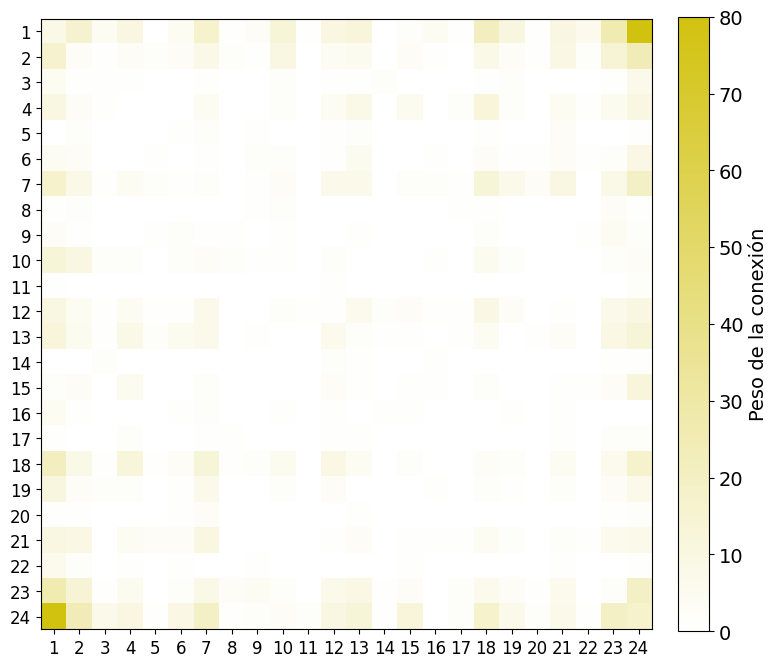

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap,to_rgb

C = nx.adjacency_matrix(G1).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Verde
color_hex = '#d2c210'  # Cambia este valor por el hexadecimal que desees
verde_personalizado = LinearSegmentedColormap.from_list(
    'verde_personalizado',                # nombre del mapa
    [(1, 1, 1), to_rgb(color_hex)]        # blanco → color hexadecimal
)


im = ax.imshow(C, cmap=verde_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.savefig("matriz_adyacencia_timbues.png", dpi=300, bbox_inches='tight')

plt.show()

In [10]:
print(unique_nodes)
print(nodo_a_sublista)
print(unique_nodes1)
print(nodo_a_sublista1)

{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
{0: (1, 2, 3, 4), 1: (1, 2, 4, 3), 2: (1, 3, 2, 4), 3: (1, 3, 4, 2), 4: (1, 4, 2, 3), 5: (1, 4, 3, 2), 6: (2, 1, 3, 4), 7: (2, 1, 4, 3), 8: (2, 3, 1, 4), 9: (2, 3, 4, 1), 10: (2, 4, 1, 3), 11: (2, 4, 3, 1), 12: (3, 1, 2, 4), 13: (3, 1, 4, 2), 14: (3, 2, 1, 4), 15: (3, 2, 4, 1), 16: (3, 4, 1, 2), 17: (3, 4, 2, 1), 18: (4, 1, 2, 3), 19: (4, 1, 3, 2), 20: (4, 2, 1, 3), 21: (4, 2, 3, 1), 22: (4, 3, 1, 2), 23: (4, 3, 2, 1)}
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, 

In [11]:
nodos_activos = contar_nodos_activos(G1)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


## W OPTIMO

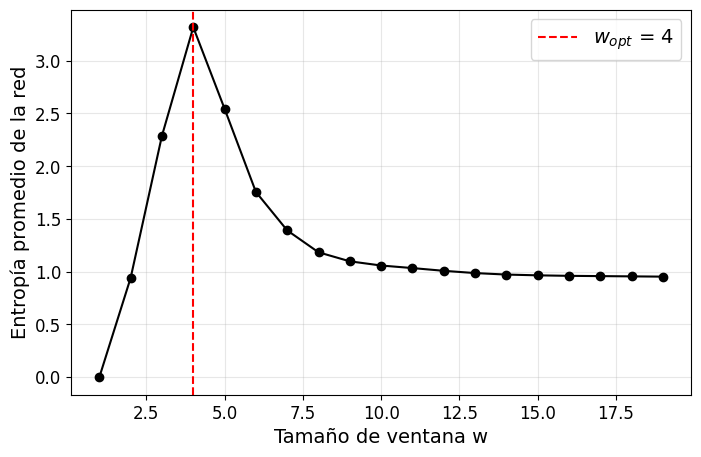

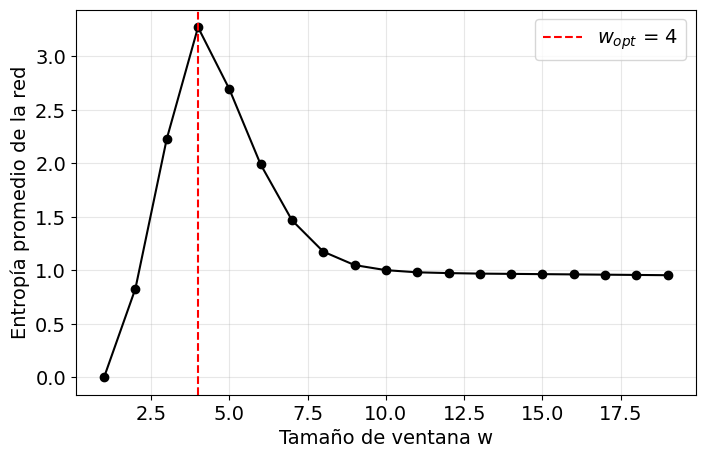

4
4


In [12]:
ventana=optimizar_w(x,1,20)
ventana1=optimizar_w(x1,1,20)
print(ventana)
print(ventana1)

##INTERSECCIÓN

NIÑO 3.4
[[37 21  8  5  1  3 15  1  3  6  1 11 10  2  4  3  3 14  5  0  8 16 24 66]
 [21  3  3  4  1  4  7  2  2  2  1  2  3  0  1  1  2 11  1  0  1  2  7 20]
 [ 8  3  0  3  0  0  3  0  1  0  0  4  1  0  0  0  0  1  1  0  3  0  3  9]
 [ 5  4  3  0  1  0  3  1  0  0  0  1  4  1  2  1  1  6  0  0  1  4  3  7]
 [ 1  1  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0  1  0  0  1  1  0  3]
 [ 3  4  0  0  0  0  2  1  1  0  0  1  1  1  2  0  0  5  2  1  2  2  2  6]
 [15  7  3  3  0  2  8  0  0  2  1  2  1  0  2  1  0  5  2  1  3  6 10 13]
 [ 1  2  0  1  0  1  0  0  0  0  1  0  0  1  1  0  0  0  2  0  0  0  1  7]
 [ 3  2  1  0  0  1  0  0  0  1  0  0  1  1  1  0  0  0  2  0  1  0  2  2]
 [ 6  2  0  0  0  0  2  0  1  0  0  0  2  0  0  0  1  5  0  1  2  0  2  9]
 [ 1  1  0  0  0  0  1  1  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  2]
 [11  2  4  1  1  1  2  0  0  0  0  0  2  1  2  0  0  3  4  0  0  2  6 12]
 [10  3  1  4  0  1  1  0  1  2  0  2  0  0  0  0  0  5  0  0  3  1  6 17]
 [ 2  0  0  1  0

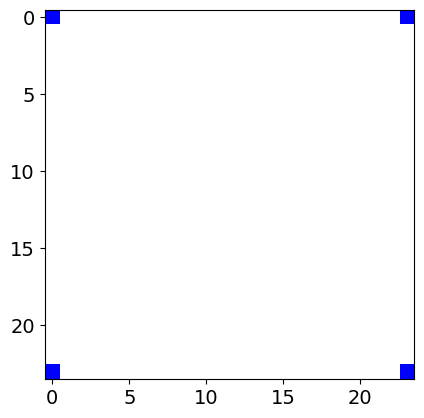

In [13]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)

# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

cmap = ListedColormap(['white', 'blue'])
plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')



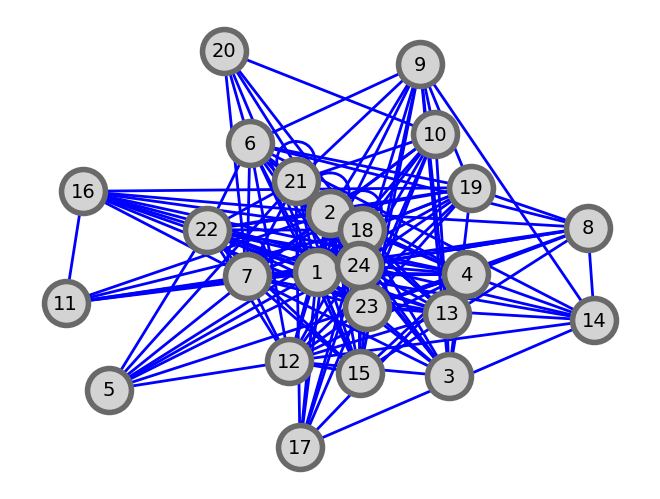

In [14]:
G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}

nx.draw(
    G, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='blue',
    width=2,
    font_size=14
)
plt.savefig("grafo_nino34_timbues.png", dpi=300, bbox_inches='tight')

plt.show()

CALAMAR
[[ 8 16  4 10  0  4 17  1  3 13  1 10 12  0  2  4  1 21 11  1 10  6 26 80]
 [16  3  1  3  2  3  8  2  1 10  0  4  5  0  3  1  0  8  3  1  9  2 14 24]
 [ 4  1  1  1  0  0  1  0  0  2  0  1  1  2  0  0  0  1  2  0  0  0  1  7]
 [10  3  1  0  0  0  4  0  0  2  0  4  8  0  5  0  2 12  2  0  4  1  5 10]
 [ 0  2  0  0  0  1  2  0  1  0  0  1  2  0  0  0  0  1  0  0  3  0  0  1]
 [ 4  3  0  0  1  0  1  0  2  2  0  1  5  0  0  1  0  3  1  1  3  1  2  9]
 [17  8  1  4  2  1  2  0  1  3  0  7  7  0  2  2  1 13  7  3 10  0  8 19]
 [ 1  2  0  0  0  0  0  0  1  2  0  0  0  0  0  0  1  1  0  0  0  0  3  1]
 [ 3  1  0  0  1  2  1  1  0  1  0  0  1  0  0  0  0  2  0  0  0  1  4  2]
 [13 10  2  2  0  2  3  2  1  1  0  2  0  0  0  1  0  5  2  0  0  0  2  3]
 [ 1  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  2]
 [10  4  1  4  1  1  7  0  0  2  1  1  6  2  3  1  1  9  3  0  1  0  7 10]
 [12  5  1  8  2  5  7  0  1  0  0  6  2  1  1  0  1  4  0  1  3  0  9 13]
 [ 0  0  2  0  0 

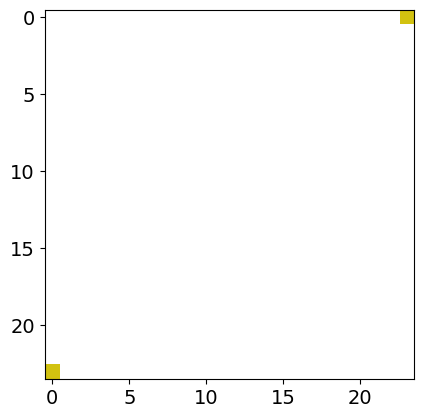

In [15]:
print("CALAMAR")
print(A1)
# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A1))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A1) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

cmap = ListedColormap(['white', '#d2c210'])
plt.imshow(A1, cmap=cmap, interpolation='nearest')


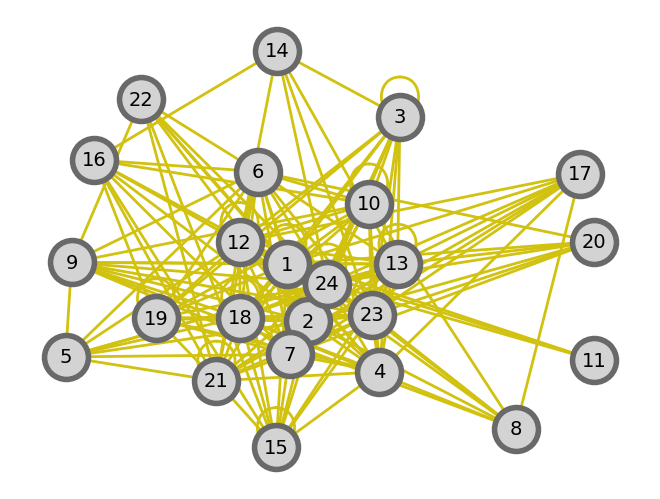

In [16]:
G1 = nx.from_numpy_array(A1)
pos = nx.spring_layout(G1, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G1.nodes()}

nx.draw(
    G1, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='#d2c210',
    width=2,
    font_size=14
)
plt.savefig("grafo_ordinal_timbues.png", dpi=300, bbox_inches='tight')

plt.show()

In [17]:
print(A.shape, A1.shape)

(24, 24) (24, 24)


##INTERSECCIÓN


In [18]:
C = np.divide(A1 ,A, out=np.zeros_like(A, dtype=float), where=A!=0) * 100
C_clean = np.where(np.isinf(C), 0, C)
#print(C_clean)
C_clean_beauty = np.array(C_clean, dtype=int)
print(C_clean_beauty)

[[ 21  76  50 200   0 133 113 100 100 216 100  90 120   0  50 133  33 150
  220   0 125  37 108 121]
 [ 76 100  33  75 200  75 114 100  50 500   0 200 166   0 300 100   0  72
  300   0 900 100 200 120]
 [ 50  33   0  33   0   0  33   0   0   0   0  25 100   0   0   0   0 100
  200   0   0   0  33  77]
 [200  75  33   0   0   0 133   0   0   0   0 400 200   0 250   0 200 200
    0   0 400  25 166 142]
 [  0 200   0   0   0   0   0   0   0   0   0 100   0   0   0   0   0 100
    0   0 300   0   0  33]
 [133  75   0   0   0   0  50   0 200   0   0 100 500   0   0   0   0  60
   50 100 150  50 100 150]
 [113 114  33 133   0  50  25   0   0 150   0 350 700   0 100 200   0 260
  350 300 333   0  80 146]
 [100 100   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0 300  14]
 [100  50   0   0   0 200   0   0   0 100   0   0 100   0   0   0   0   0
    0   0   0   0 200 100]
 [216 500   0   0   0   0 150   0 100   0   0   0   0   0   0   0   0 100
    0   0   0   0

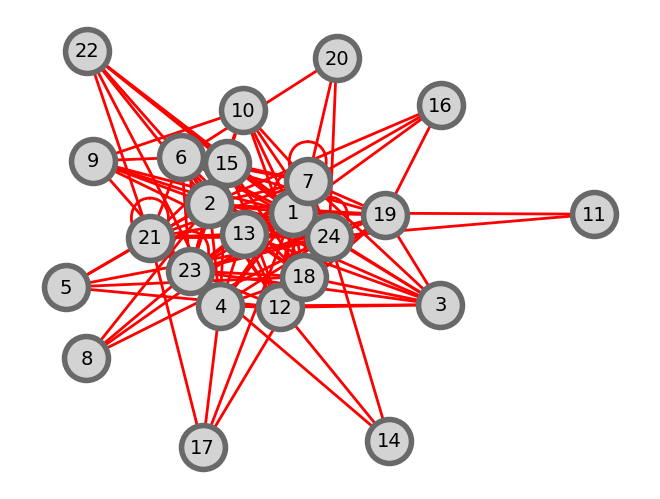

In [19]:
GC = nx.from_numpy_array(C_clean)
pos = nx.spring_layout(GC, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in GC.nodes()}

nx.draw(
    GC, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='red',
    width=2,
    font_size=14
)
plt.savefig("grafo_influencia_timbues.png", dpi=300, bbox_inches='tight')

plt.show()

INTERCEPCIÓN
M = 131.0


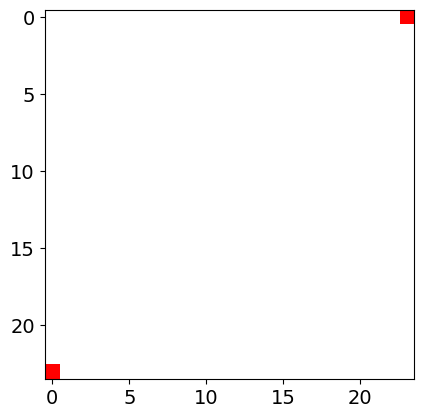

In [20]:
print("INTERCEPCIÓN")
#print(C_clean)
cmap = ListedColormap(['white', 'red'])

# contar diagonal (loops)
loops = np.count_nonzero(np.diag(C_clean))

# contar fuera de la diagonal
off_diag = np.count_nonzero(C_clean) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

plt.imshow(A1, cmap=cmap, interpolation='nearest')

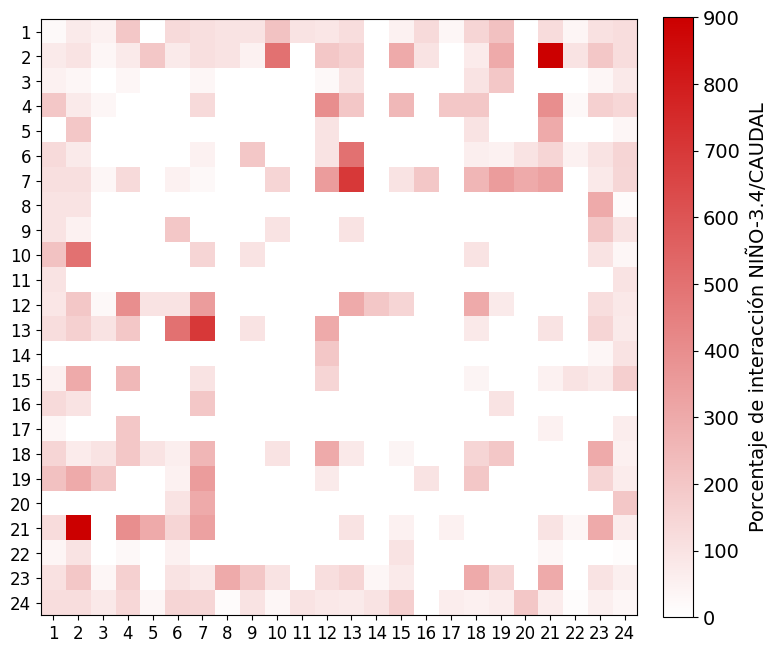

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(GC).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Rojo
rojo_personalizado = LinearSegmentedColormap.from_list(
    'rojo_personalizado',
    [(1, 1, 1), (0.8, 0, 0)]  # Blanco → Rojo
)

im = ax.imshow(C, cmap=rojo_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Porcentaje de interacción NIÑO-3.4/CAUDAL', fontsize=14)

plt.tight_layout()
plt.savefig("matriz_influencia_timbues.png", dpi=300, bbox_inches='tight')

plt.show()



In [22]:
nodos_activos = contar_nodos_activos(GC)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


#PORCENTAJE DE INTERACCIÓN

In [23]:
upper = np.triu(C_clean)
promedio = np.mean(upper)
print("La influencia del NIÑO 3.4 en el caudal es:",promedio,"%")

La influencia del NIÑO 3.4 en el caudal es: 33.272752261616084 %


##MÉTRICAS

In [24]:
import networkx as nx
import numpy as np

# Intento de importar correctamente python-louvain
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red(G, nombre_grafo):
    """
    Calcula e imprime métricas de red considerando solo nodos activos.
    Las etiquetas en pantalla se muestran como 1‑based.
    """
    print(f"\n=== Métricas para {nombre_grafo} ===")

    # Identificar nodos activos (grado > 0)
    nodos_activos = [n for n in G.nodes() if G.degree(n) > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos activos: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos activos. No se pueden calcular métricas.")
        return

    # Subgrafo inducido por los nodos activos
    G_activo = G.subgraph(nodos_activos).copy()

    # ---- Grado medio (solo activos) ----
    grados = [d for n, d in G_activo.degree()]
    grado_medio = np.mean(grados)
    print(f"Grado medio (solo activos): {grado_medio:.4f}")

    # ---- Coeficiente de clustering promedio (solo activos) ----
    clustering = nx.average_clustering(G, nodes=nodos_activos)
    print(f"Coeficiente de clustering promedio (solo activos): {clustering:.4f}")

    # ---- Diámetro y distancia promedio ----
    if nx.is_connected(G_activo):
        diametro = nx.diameter(G_activo)
        dist_prom = nx.average_shortest_path_length(G_activo)
        print(f"Diámetro (componente activa): {diametro}")
        print(f"Distancia promedio (componente activa): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante)
        dist_prom = nx.average_shortest_path_length(G_gigante)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro: {diametro}")
        print(f"  Distancia promedio: {dist_prom:.4f}")

    # ---- Modularidad (sobre grafo activo) ----
    # (Requiere python-louvain instalado)
    particion = community_louvain.best_partition(G_activo)
    modularidad = community_louvain.modularity(particion, G_activo)
    print(f"Modularidad (sobre grafo activo): {modularidad:.4f}")

    # ---- Centralidades ----
    # Centralidad de grado (solo activos)
    cent_grado = nx.degree_centrality(G_activo)
    prom_cent_grado = np.mean(list(cent_grado.values()))
    print(f"Centralidad de grado promedio (activos): {prom_cent_grado:.4f}")

    # Top 3 nodos con mayor centralidad de grado (etiquetas 1‑based)
    top_nodos = sorted(cent_grado.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos activos con mayor centralidad de grado:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.4f}")

    # Centralidad de cercanía (sobre la componente usada)
    if nx.is_connected(G_activo):
        cent_cercania = nx.closeness_centrality(G_activo)
    else:
        cent_cercania = nx.closeness_centrality(G_gigante)
    prom_cent_cercania = np.mean(list(cent_cercania.values()))
    print(f"Centralidad de cercanía promedio (componente usada): {prom_cent_cercania:.4f}")

    # Centralidad de intermediación (betweenness) sobre todo el grafo activo
    cent_inter = nx.betweenness_centrality(G_activo)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio (activos): {prom_cent_inter:.4f}")

In [25]:
calcular_metricas_red(G, "NIÑO 3.4")
calcular_metricas_red(G1, "TIMBUES")
calcular_metricas_red(GC, "INTERSECCIÓN")


=== Métricas para NIÑO 3.4 ===
Nodos activos: 24 de 24
Grado medio (solo activos): 14.5000
Coeficiente de clustering promedio (solo activos): 0.7481
Diámetro (componente activa): 2
Distancia promedio (componente activa): 1.3949
Modularidad (sobre grafo activo): 0.0771
Centralidad de grado promedio (activos): 0.6304
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 1.0870
  Nodo 1: 1.0435
  Nodo 2: 1.0000
Centralidad de cercanía promedio (componente usada): 0.7337
Centralidad de intermediación promedio (activos): 0.0180

=== Métricas para TIMBUES ===
Nodos activos: 24 de 24
Grado medio (solo activos): 14.5833
Coeficiente de clustering promedio (solo activos): 0.7748
Diámetro (componente activa): 2
Distancia promedio (componente activa): 1.4130
Modularidad (sobre grafo activo): 0.0764
Centralidad de grado promedio (activos): 0.6341
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 1.0435
  Nodo 1: 1.0000
  Nodo 2: 0.9565
Centralidad de cercanía promedio (compon

##MÉTRICAS PESADAS

In [43]:
# ── Reconstrucción de A, A1 con pesos flotantes (sin truncar a int) ──────────
# Las celdas anteriores sobreescriben A y A1 con dtype=int para visualización,
# lo que destruye los pesos. Aquí los reconstruimos antes de las métricas pesadas.

patrones_x  = obtener_patrones(x,  w_opt)
patrones_x1 = obtener_patrones(x1, w_opt)

G_temp,  _, _ = crear_grafo(crear_ind(x,  w_opt), w_opt)
G1_temp, _, _ = crear_grafo(crear_ind(x1, w_opt), w_opt)

A  = nx.to_numpy_array(G_temp)   # float64, pesos reales
A1 = nx.to_numpy_array(G1_temp)  # float64, pesos reales

G  = nx.from_numpy_array(A)
G1 = nx.from_numpy_array(A1)

print("A y A1 restaurados con pesos flotantes.")
print(f"  dtype A: {A.dtype},  peso máximo en A: {A.max():.4f}")
print(f"  dtype A1: {A1.dtype}, peso máximo en A1: {A1.max():.4f}")

A y A1 restaurados con pesos flotantes.
  dtype A: float64,  peso máximo en A: 66.0000
  dtype A1: float64, peso máximo en A1: 80.0000


In [46]:
print("Pesos en G:", [d['weight'] for u,v,d in G.edges(data=True)][:10])
print("Pesos en G1:", [d['weight'] for u,v,d in G1.edges(data=True)][:10])
print("Fuerza media G:", np.mean(list(dict(G.degree(weight='weight')).values())))
print("Fuerza media G1:", np.mean(list(dict(G1.degree(weight='weight')).values())))

Pesos en G: [37.0, 21.0, 8.0, 5.0, 1.0, 3.0, 15.0, 1.0, 3.0, 6.0]
Pesos en G1: [8.0, 16.0, 4.0, 10.0, 4.0, 17.0, 1.0, 3.0, 13.0, 1.0]
Fuerza media G: 69.0
Fuerza media G1: 69.0


In [47]:
print("A dtype:", A.dtype)
print("A1 dtype:", A1.dtype)
print("Valores únicos en A:", np.unique(A))
print("Valores únicos en A1:", np.unique(A1))

A dtype: float64
A1 dtype: float64
Valores únicos en A: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 20. 21. 24. 31. 32. 37. 49. 66.]
Valores únicos en A1: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 16. 17. 19.
 21. 24. 26. 80.]


In [44]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red_pesada(G, nombre_grafo, usar_inverso_para_distancias=True):
    """
    Calcula e imprime métricas de red considerando pesos en las aristas.

    Parámetros:
    - G: grafo de NetworkX con aristas que tienen atributo 'weight'
    - nombre_grafo: título para la salida
    - usar_inverso_para_distancias: si True, usa 1/weight como distancia para caminos;
      si False, ignora los pesos para distancias (trata como no pesado).
    """
    print(f"\n=== Métricas PESADAS para {nombre_grafo} ===")

    # Nodos activos (grado no pesado > 0, pero usaremos fuerza > 0 para activos pesados)
    # Consideramos nodos activos aquellos con fuerza > 0
    fuerzas = dict(G.degree(weight='weight'))
    nodos_activos = [n for n, f in fuerzas.items() if f > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos con fuerza > 0: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos con fuerza positiva. No se pueden calcular métricas.")
        return

    # ---- Grado medio pesado (fuerza promedio) ----
    fuerza_promedio = np.mean(list(fuerzas.values()))
    print(f"Fuerza promedio (grado pesado): {fuerza_promedio:.4f}")

    # ---- Coeficiente de clustering pesado ----
    # Utiliza la definición estándar de clustering pesado de NetworkX
    clustering_pesado = nx.average_clustering(G, weight='weight')
    print(f"Coeficiente de clustering pesado promedio: {clustering_pesado:.4f}")

    # ---- Preparar grafo con distancias (inverso del peso) si se requiere ----
    if usar_inverso_para_distancias:
        # Crear una copia del grafo con atributo 'distance' = 1/weight
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
    else:
        G_dist = G  # usa el grafo original sin considerar pesos para distancias

    # ---- Diámetro y distancia promedio pesados ----
    # Se calculan sobre el subgrafo de nodos activos (para evitar aislados)
    G_activo = G.subgraph(nodos_activos).copy()
    if usar_inverso_para_distancias:
        G_dist_activo = G_dist.subgraph(nodos_activos).copy()
    else:
        G_dist_activo = G_activo

    if nx.is_connected(G_dist_activo):
        diametro = nx.diameter(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        print(f"Diámetro (pesado): {diametro}")
        print(f"Distancia promedio (pesada): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_dist_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_dist_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro (pesado): {diametro}")
        print(f"  Distancia promedio (pesada): {dist_prom:.4f}")

    # ---- Modularidad pesada ----
    # La partición de Louvain puede usar pesos
    particion = community_louvain.best_partition(G, weight='weight')
    modularidad = community_louvain.modularity(particion, G, weight='weight')
    print(f"Modularidad (pesada): {modularidad:.4f}")

    # ---- Centralidades pesadas ----
    # Centralidad de grado pesada (fuerza normalizada)
    # Normalizamos por la suma total de fuerzas de la red (o por el máximo posible)
    total_fuerza = sum(fuerzas.values())
    cent_fuerza = {n: f / total_fuerza for n, f in fuerzas.items()}
    prom_cent_fuerza = np.mean(list(cent_fuerza.values()))
    print(f"Centralidad de fuerza promedio: {prom_cent_fuerza:.6f}")

    # Top 3 nodos con mayor fuerza (etiquetas 1‑based)
    top_nodos = sorted(fuerzas.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos con mayor fuerza:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.2f}")

    # Centralidad de cercanía pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        # Usar el grafo con distancias (G_dist)
        cent_cercania = nx.closeness_centrality(G_dist, distance='distance')
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (pesada, con inverso): {prom_cent_cercania:.6f}")
    else:
        # Versión no pesada (longitudes de camino = 1 por arista)
        cent_cercania = nx.closeness_centrality(G)
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (no pesada): {prom_cent_cercania:.6f}")

    # Centralidad de intermediación pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        cent_inter = nx.betweenness_centrality(G_dist, weight='distance')
    else:
        cent_inter = nx.betweenness_centrality(G, weight=None)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio: {prom_cent_inter:.6f}")

In [45]:
# Para NIÑO 3.4 (G)
calcular_metricas_red_pesada(G, "NIÑO 3.4")

# Para CAUDAL (G1)
calcular_metricas_red_pesada(G1, "TIMBUES")

# Para INTERSECCIÓN (GC, si existe)
calcular_metricas_red_pesada(GC, "INTERSECCIÓN")


=== Métricas PESADAS para NIÑO 3.4 ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 69.0000
Coeficiente de clustering pesado promedio: 0.0398
Diámetro (pesado): 1.5
Distancia promedio (pesada): 0.3841
Modularidad (pesada): 0.0699
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 378.00
  Nodo 1: 304.00
  Nodo 23: 119.00
Centralidad de cercanía promedio (pesada, con inverso): 3.090571
Centralidad de intermediación promedio: 0.046113

=== Métricas PESADAS para TIMBUES ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 69.0000
Coeficiente de clustering pesado promedio: 0.0372
Diámetro (pesado): 1.1
Distancia promedio (pesada): 0.3767
Modularidad (pesada): 0.0764
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 283.00
  Nodo 1: 269.00
  Nodo 2: 126.00
Centralidad de cercanía promedio (pesada, con inverso): 3.111878
Centralidad de intermediación promedio: 0.059124

=== Métricas PESADAS para I

In [28]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos.
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas de un grafo
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        grados = [d for n, d in G.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G))
        if nx.is_connected(G):
            diametro = float(nx.diameter(G))
            dist_prom = float(nx.average_shortest_path_length(G))
        else:
            comps = list(nx.connected_components(G))
            if comps:
                G_gig = G.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G)
            modularidad = float(community_louvain.modularity(particion, G))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        if nx.is_connected(G):
            cent_cercania = nx.closeness_centrality(G)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas de un grafo
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        fuerzas = dict(G.degree(weight='weight'))
        fuerza_media = float(np.mean(list(fuerzas.values())))
        clustering_pesado = float(nx.average_clustering(G, weight='weight'))
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            diam_pesado = dist_prom_pesado = None
        else:
            G_activo = G.subgraph(nodos_activos).copy()
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if nx.is_connected(G_dist_activo):
                diam_pesado = float(nx.diameter(G_dist_activo, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_dist_activo, weight='distance'))
            else:
                comps = list(nx.connected_components(G_dist_activo))
                if comps:
                    G_gig = G_dist_activo.subgraph(max(comps, key=len)).copy()
                    diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                    dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
                else:
                    diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas.values())
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([f/total_fuerza for f in fuerzas.values()]))
        else:
            cent_fuerza_prom = 0.0
        if nodos_activos:
            cent_cercania_pesada = nx.closeness_centrality(G_dist, distance='distance')
            prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
        else:
            prom_cent_cercania_pesada = None
        cent_inter_pesada = nx.betweenness_centrality(G_dist, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            # Formatear los números con la precisión indicada
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        # Unir los tres pares con comas
        resultado[met] = ",".join(pares)

    return resultado

In [29]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (14.50,69.00),(14.58,69.00),(10.92,1597.09)
clustering = (0.75,0.04),(0.77,0.04),(0.80,0.11)
diametro = (2.00,1.50),(2.00,1.10),(3.00,0.03)
distancia_promedio = (1.39,0.38),(1.41,0.38),(1.55,0.01)
modularidad = (0.08,0.08),(0.08,0.08),(0.19,0.19)
cent_grado_prom = (0.63,0.04),(0.63,0.04),(0.47,0.04)
cent_cercania_prom = (0.73,3.09),(0.73,3.11),(0.66,111.00)
cent_inter_prom = (0.02,0.05),(0.02,0.06),(0.03,0.06)


##Para nodos disponibles

In [48]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos,
    considerando únicamente los nodos activos (grado > 0 o fuerza > 0).
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas (solo nodos activos)
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Nodos activos: grado no ponderado > 0
        nodos_activos = [n for n, d in G.degree() if d > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        grados = [d for n, d in G_activo.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G_activo))
        # Diámetro y distancia promedio sobre la componente conexa más grande
        if nx.is_connected(G_activo):
            diametro = float(nx.diameter(G_activo))
            dist_prom = float(nx.average_shortest_path_length(G_activo))
        else:
            comps = list(nx.connected_components(G_activo))
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G_activo)
            modularidad = float(community_louvain.modularity(particion, G_activo))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G_activo)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        # Centralidad de cercanía sobre la componente usada
        if nx.is_connected(G_activo):
            cent_cercania = nx.closeness_centrality(G_activo)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                cent_cercania = nx.closeness_centrality(G_gig)
                prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
            else:
                prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G_activo)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas (solo nodos con fuerza > 0)
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Fuerzas (grados ponderados)
        fuerzas = dict(G.degree(weight='weight'))
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        # Fuerza media sobre nodos activos
        fuerza_media = float(np.mean([fuerzas[n] for n in nodos_activos]))
        clustering_pesado = float(nx.average_clustering(G_activo, weight='weight'))
        # Construir grafo de distancias (inverso del peso)
        G_dist = nx.Graph()
        for u, v, data in G_activo.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        # Diámetro y distancia promedio pesados sobre la componente conexa más grande
        if nx.is_connected(G_dist):
            diam_pesado = float(nx.diameter(G_dist, weight='distance'))
            dist_prom_pesado = float(nx.average_shortest_path_length(G_dist, weight='distance'))
        else:
            comps = list(nx.connected_components(G_dist))
            if comps:
                G_gig = G_dist.subgraph(max(comps, key=len)).copy()
                diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
            else:
                diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G_activo, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G_activo, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas[n] for n in nodos_activos)
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([fuerzas[n]/total_fuerza for n in nodos_activos]))
        else:
            cent_fuerza_prom = 0.0
        # Centralidad de cercanía pesada sobre el grafo de distancias (solo activos)
        if nodos_activos:
            # Asegurar que trabajamos sobre el subgrafo de distancias con nodos activos
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if G_dist_activo.number_of_nodes() > 0:
                cent_cercania_pesada = nx.closeness_centrality(G_dist_activo, distance='distance')
                prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
            else:
                prom_cent_cercania_pesada = None
        else:
            prom_cent_cercania_pesada = None
        # Centralidad de intermediación pesada (sobre el grafo de distancias, activos)
        cent_inter_pesada = nx.betweenness_centrality(G_dist_activo, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        resultado[met] = ",".join(pares)

    return resultado

In [49]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (14.50,69.00),(14.58,69.00),(10.92,1597.09)
clustering = (0.75,0.04),(0.77,0.04),(0.80,0.11)
diametro = (2.00,1.50),(2.00,1.10),(3.00,0.03)
distancia_promedio = (1.39,0.38),(1.41,0.38),(1.55,0.01)
modularidad = (0.08,0.08),(0.08,0.07),(0.19,0.18)
cent_grado_prom = (0.63,0.04),(0.63,0.04),(0.47,0.04)
cent_cercania_prom = (0.73,3.09),(0.73,3.11),(0.66,111.00)
cent_inter_prom = (0.02,0.05),(0.02,0.06),(0.03,0.06)


In [33]:
!pip install powerlaw

##DISTRIBUCIONES

In [34]:
import powerlaw
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.ticker as ticker
from scipy.stats import skew, kurtosis

def plot_degree_distribution(G, nombre_grafo, color='blue', bins=None, loglog=False):
    """
    Calcula y grafica la distribución de probabilidad de grado (no dirigido).
    Incluye estadísticas y el exponente γ de la ley de potencia.
    """
    grados = [d for n, d in G.degree()]
    grados = np.array(grados)

    # Estadísticas
    media = np.mean(grados)
    varianza = np.var(grados, ddof=1)
    asimetria = skew(grados)
    curt = kurtosis(grados)
    momento2 = np.mean(grados**2)  # ⟨k²⟩

    # Ajuste de ley de potencia
    fit = powerlaw.Fit(grados, discrete=True, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (sin curva de ajuste)
    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(grados, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad P(k)')
        titulo = f'Distribución de grado (log-log) - {nombre_grafo}'
    else:
        sns.histplot(grados, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado - {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados en consola
    print(f"Distribución de grado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨k²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Grado mínimo: {grados.min()}, máximo: {grados.max()}\n")


def plot_degree_distribution_pesada(G, nombre_grafo, color='green', bins=20, loglog=False):
    """
    Para grado pesado (fuerza). Similar a la anterior.
    """
    fuerzas = list(dict(G.degree(weight='weight')).values())
    fuerzas = np.array(fuerzas)

    media = np.mean(fuerzas)
    varianza = np.var(fuerzas, ddof=1)
    asimetria = skew(fuerzas)
    curt = kurtosis(fuerzas)
    momento2 = np.mean(fuerzas**2)

    fit = powerlaw.Fit(fuerzas, discrete=False, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(fuerzas, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Fuerza (s)')
        ax.set_ylabel('Probabilidad P(s)')
        titulo = f'Distribución de fuerza (log-log) - {nombre_grafo}'
    else:
        sns.histplot(fuerzas, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado pesado (s)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado pesado- {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 14,
        'axes.labelsize': 14,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
    })
    plt.show()

    print(f"Distribución de grado pesado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨s²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Fuerza mínima: {fuerzas.min():.2f}, máxima: {fuerzas.max():.2f}\n")


def plot_degree_distribution_directed(G, nombre_grafo, color_in='blue', color_out='red', bins=None, loglog=False):
    """
    Para redes dirigidas: calcula y grafica por separado las distribuciones
    de grado de entrada (in-degree) y salida (out-degree), con sus respectivos γ.
    """
    in_degrees = np.array([d for n, d in G.in_degree()])
    out_degrees = np.array([d for n, d in G.out_degree()])

    # Estadísticas in
    media_in = np.mean(in_degrees)
    varianza_in = np.var(in_degrees, ddof=1)
    asimetria_in = skew(in_degrees)
    curt_in = kurtosis(in_degrees)
    momento2_in = np.mean(in_degrees**2)

    # Estadísticas out
    media_out = np.mean(out_degrees)
    varianza_out = np.var(out_degrees, ddof=1)
    asimetria_out = skew(out_degrees)
    curt_out = kurtosis(out_degrees)
    momento2_out = np.mean(out_degrees**2)

    # Ajustes ley potencia
    fit_in = powerlaw.Fit(in_degrees, discrete=True, verbose=False)
    gamma_in = fit_in.power_law.alpha
    sigma_in = fit_in.power_law.sigma
    xmin_in = fit_in.power_law.xmin
    p_in = fit_in.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fit_out = powerlaw.Fit(out_degrees, discrete=True, verbose=False)
    gamma_out = fit_out.power_law.alpha
    sigma_out = fit_out.power_law.sigma
    xmin_out = fit_out.power_law.xmin
    p_out = fit_out.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (dos subplots)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    if loglog:
        # In-degree
        hist_in, bins_in = np.histogram(in_degrees, bins=bins, density=True)
        bin_centers_in = (bins_in[:-1] + bins_in[1:]) / 2
        ax1.loglog(bin_centers_in, hist_in, 'o', color=color_in, markersize=5)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad P(k_in)')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        # Out-degree
        hist_out, bins_out = np.histogram(out_degrees, bins=bins, density=True)
        bin_centers_out = (bins_out[:-1] + bins_out[1:]) / 2
        ax2.loglog(bin_centers_out, hist_out, 'o', color=color_out, markersize=5)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad P(k_out)')
        ax2.set_title(f'Out-degree - {nombre_grafo}')
    else:
        sns.histplot(in_degrees, bins=bins, stat='probability', color=color_in, alpha=0.7, ax=ax1)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        sns.histplot(out_degrees, bins=bins, stat='probability', color=color_out, alpha=0.7, ax=ax2)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad')
        ax2.set_title(f'Out-degree - {nombre_grafo}')

    for ax in [ax1, ax2]:
        ax.grid(False)  # grid desactivado
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados
    print(f"Distribuciones de grado (dirigido) - {nombre_grafo}")
    print("  IN-DEGREE:")
    print(f"    Estadísticas: media={media_in:.4f}, varianza={varianza_in:.4f}, asimetría={asimetria_in:.4f}, curtosis={curt_in:.4f}")
    print(f"    Segundo momento ⟨k_in²⟩ = {momento2_in:.4f}")
    print(f"    γ_in = {gamma_in:.4f} ± {sigma_in:.4f} (xmin={xmin_in}), p={p_in:.4f}")
    print("  OUT-DEGREE:")
    print(f"    Estadísticas: media={media_out:.4f}, varianza={varianza_out:.4f}, asimetría={asimetria_out:.4f}, curtosis={curt_out:.4f}")
    print(f"    Segundo momento ⟨k_out²⟩ = {momento2_out:.4f}")
    print(f"    γ_out = {gamma_out:.4f} ± {sigma_out:.4f} (xmin={xmin_out}), p={p_out:.4f}\n")

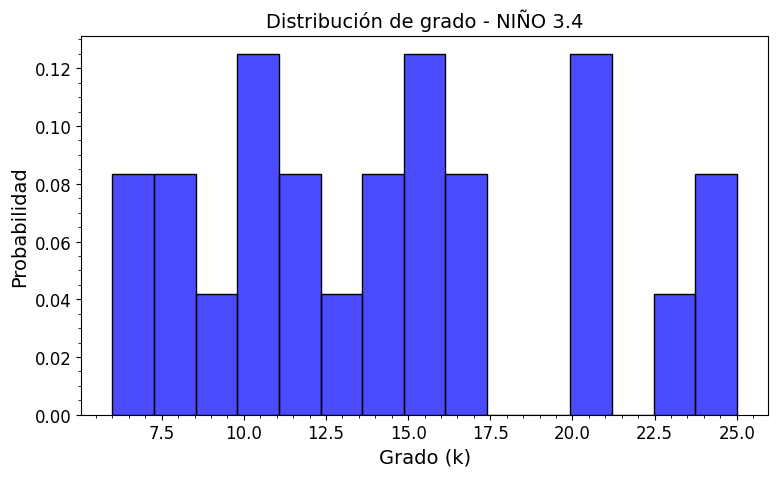

Distribución de grado - NIÑO 3.4
  Estadísticas: media=14.5000, varianza=31.0435, asimetría=0.3513, curtosis=-0.9280
  Segundo momento ⟨k²⟩ = 240.0000
  Exponente γ = 2.9971 ± 0.4582 (xmin = 10.0)
  p-valor (vs. exponencial) = 0.0018
  Grado mínimo: 6, máximo: 25



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


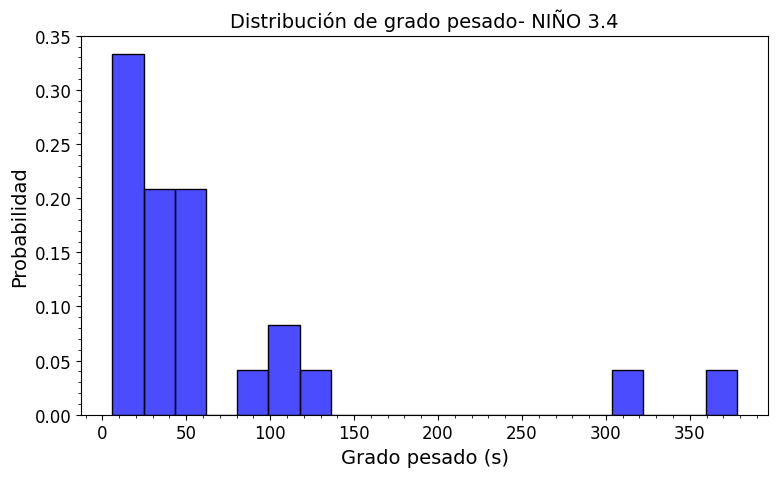

Distribución de grado pesado - NIÑO 3.4
  Estadísticas: media=69.0000, varianza=8223.3913, asimetría=2.4475, curtosis=5.2293
  Segundo momento ⟨s²⟩ = 12641.7500
  Exponente γ = 2.3283 ± 0.3321 (xmin = 33.0)
  p-valor (vs. exponencial) = 0.1677
  Fuerza mínima: 6.00, máxima: 378.00



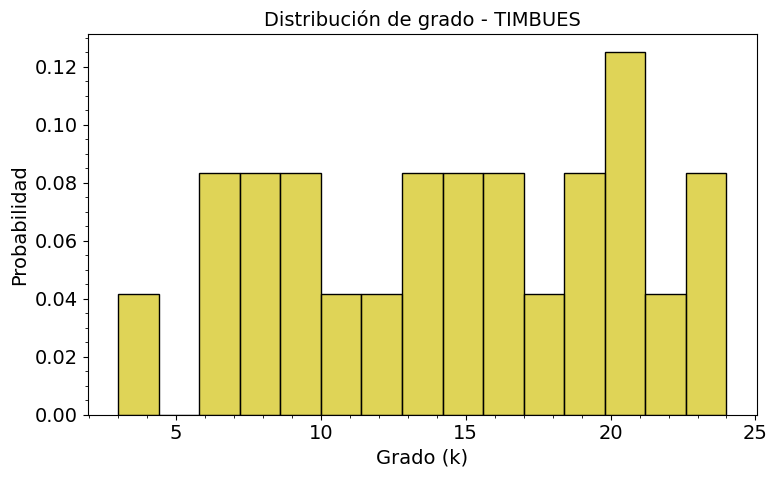

Distribución de grado - TIMBUES
  Estadísticas: media=14.5833, varianza=36.3406, asimetría=-0.1633, curtosis=-1.1167
  Segundo momento ⟨k²⟩ = 247.5000
  Exponente γ = 2.0784 ± 0.2249 (xmin = 6.0)
  p-valor (vs. exponencial) = 0.0000
  Grado mínimo: 3, máximo: 24



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


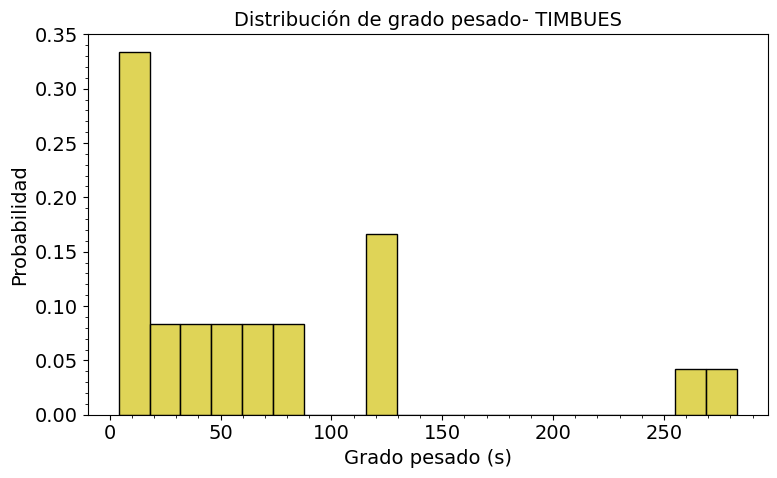

Distribución de grado pesado - TIMBUES
  Estadísticas: media=69.0000, varianza=5707.4783, asimetría=1.7073, curtosis=2.3397
  Segundo momento ⟨s²⟩ = 10230.6667
  Exponente γ = 1.5957 ± 0.1242 (xmin = 8.0)
  p-valor (vs. exponencial) = 0.4984
  Fuerza mínima: 4.00, máxima: 283.00



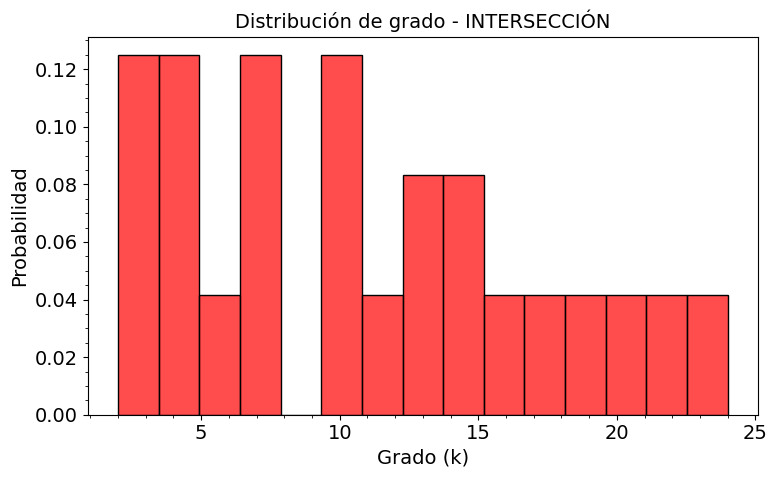

Distribución de grado - INTERSECCIÓN
  Estadísticas: media=10.9167, varianza=43.3841, asimetría=0.4096, curtosis=-0.9420
  Segundo momento ⟨k²⟩ = 160.7500
  Exponente γ = 2.4562 ± 0.3532 (xmin = 7.0)
  p-valor (vs. exponencial) = 0.0105
  Grado mínimo: 2, máximo: 24



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


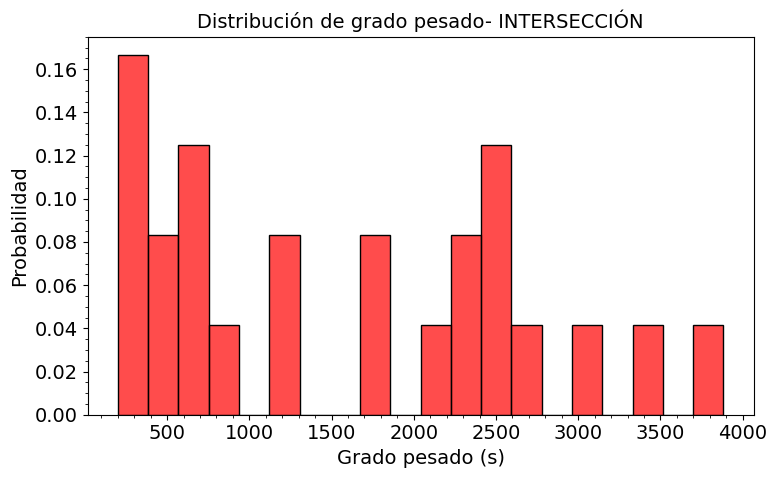

Distribución de grado pesado - INTERSECCIÓN
  Estadísticas: media=1597.0921, varianza=1216294.1197, asimetría=0.3873, curtosis=-1.0413
  Segundo momento ⟨s²⟩ = 3716318.4013
  Exponente γ = 1.7468 ± 0.1557 (xmin = 333.3333333333333)
  p-valor (vs. exponencial) = 0.0602
  Fuerza mínima: 200.00, máxima: 3883.20



In [35]:
# Suponiendo que tienes G, G1 y GC definidos
plot_degree_distribution(G, "NIÑO 3.4", color='blue', bins=15, loglog=False)
plot_degree_distribution_pesada(G, "NIÑO 3.4", color='blue', bins=20, loglog=False)

plot_degree_distribution(G1, "TIMBUES", color='#d2c210', bins=15, loglog=False)
plot_degree_distribution_pesada(G1, "TIMBUES", color='#d2c210', bins=20, loglog=False)

plot_degree_distribution(GC, "INTERSECCIÓN", color='red', bins=15, loglog=False)
plot_degree_distribution_pesada(GC, "INTERSECCIÓN", color='red', bins=20, loglog=False)

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def correlacion_pearson(x, y, nombre_x='Serie X', nombre_y='Serie Y'):
    """
    Calcula la correlación de Pearson entre dos series y genera una gráfica de dispersión.

    Parámetros:
    x, y : listas o arrays unidimensionales de la misma longitud.
    nombre_x, nombre_y : etiquetas para los ejes.

    Retorna:
    r : coeficiente de correlación de Pearson.
    p : valor p asociado.
    """
    x = np.array(x)
    y = np.array(y)
    if len(x) != len(y):
        raise ValueError("Las series deben tener la misma longitud")

    # Calcular correlación de Pearson
    r, p = stats.pearsonr(x, y)

    # Ajuste lineal para la recta de regresión
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Crear gráfica
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.6, edgecolors='k', linewidth=0.5)
    # Recta de regresión
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, 'r-', label=f'Regresión lineal (r={r:.3f})')
    plt.xlabel(nombre_x)
    plt.ylabel(nombre_y)
    #plt.title(f'Correlación de Pearson: r={r:.3f}, p={p:.3e}')
    #plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
    plt.show()

    print(f"Coeficiente de correlación de Pearson: r = {r:.4f}")
    print(f"Valor p: {p:.4e}")
    return r, p

##PEARSON

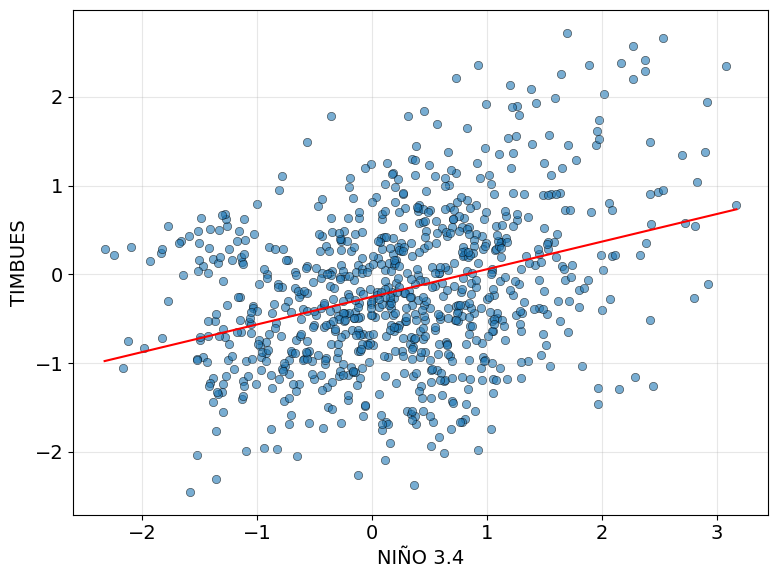

Coeficiente de correlación de Pearson: r = 0.3471
Valor p: 4.8062e-25


In [37]:
# Suponiendo que tienes las series x (NIÑO) y x1 (CALAMAR) definidas
r, p = correlacion_pearson(x1, x, nombre_y='TIMBUES', nombre_x='NIÑO 3.4')

##BOOTSTRAP

In [38]:
porcentaje_para_comparar=promedio
print(porcentaje_para_comparar)

33.272752261616084


Resultados del bootstrap clásico sobre x1 (1000 remuestras):
Media: 45.88
Mediana: 45.77
Desviación estándar: 1.97
Intervalo de confianza 95%: (42.19, 49.67)
Distancia del observado respecto a la media bootstrap: -6.39 desviaciones estándar


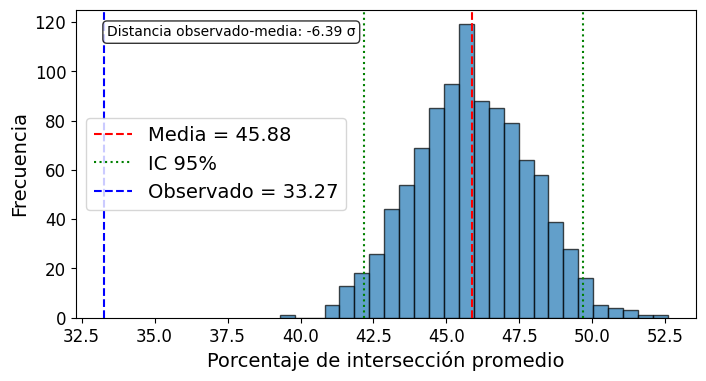

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
w_opt = 4
n_bootstrap = 1000          # número de remuestras
np.random.seed(42)          # para reproducibilidad

# Asegurarse de que A (matriz del niño) está calculada a partir de x
# Si no lo está, calcúlala aquí:
# nodos_x = crear_ind(x, w_opt)
# G_x, _, _ = crear_grafo(nodos_x, w_opt)
# A = nx.to_numpy_array(G_x, dtype=int)

# Lista para almacenar los resultados
porcents_boot = []

for i in range(n_bootstrap):
    # 1. Remuestrear x1 con reemplazo (bootstrap clásico)
    indices_boot = np.random.choice(len(x1), size=len(x1), replace=True)
    x1_boot = [x1[i] for i in indices_boot]   # si x1 es lista
    # Si x1 es array de numpy: x1_boot = x1[indices_boot]

    # 2. Obtener índices de patrones ordinales de la remuestra
    nodos_boot = crear_ind(x1_boot, w_opt)

    # 3. Construir grafo y matriz de adyacencia
    G_boot, _, _ = crear_grafo(nodos_boot, w_opt)
    A_boot = nx.to_numpy_array(G_boot, dtype=int)

    # 4. Calcular la métrica de similitud con A (la red del niño)
    with np.errstate(divide='ignore', invalid='ignore'):
        C = np.divide(A_boot, A, out=np.zeros_like(A, dtype=float), where=A != 0) * 100
    C_clean = np.where(np.isinf(C), 0, C)
    upper = np.triu(C_clean, k=1)          # triángulo superior sin diagonal
    promedio = np.mean(upper)               # promedio de todas las celdas (incluye ceros)
    # Si prefieres solo celdas con valor positivo:
    # promedio = np.mean(upper[upper > 0]) if np.any(upper > 0) else 0

    porcents_boot.append(promedio)

porcents_boot = np.array(porcents_boot)

# Estadísticos
media_boot = np.mean(porcents_boot)
mediana_boot = np.median(porcents_boot)
desv_boot = np.std(porcents_boot, ddof=1)
ic_inf = np.percentile(porcents_boot, 2.5)
ic_sup = np.percentile(porcents_boot, 97.5)
# Distancia del valor observado respecto a la media bootstrap (en desviaciones estándar)
distancia_sd = (porcentaje_para_comparar - media_boot) / desv_boot


print(f"Resultados del bootstrap clásico sobre x1 ({n_bootstrap} remuestras):")
print(f"Media: {media_boot:.2f}")
print(f"Mediana: {mediana_boot:.2f}")
print(f"Desviación estándar: {desv_boot:.2f}")
print(f"Intervalo de confianza 95%: ({ic_inf:.2f}, {ic_sup:.2f})")
print(f"Distancia del observado respecto a la media bootstrap: {distancia_sd:.2f} desviaciones estándar")

# Histograma
plt.figure(figsize=(8,4))
plt.hist(porcents_boot, bins='auto', alpha=0.7, edgecolor='black')
plt.axvline(media_boot, color='red', linestyle='--', label=f'Media = {media_boot:.2f}')
plt.axvline(ic_inf, color='green', linestyle=':', label='IC 95%')
plt.axvline(ic_sup, color='green', linestyle=':')
plt.axvline(porcentaje_para_comparar, color='blue', linestyle='--', label=f'Observado = {porcentaje_para_comparar:.2f}')
#plt.title('Distribución bootstrap de la similitud (A vs remuestras de x1)')
# Agregar anotación con la distancia en SD (opción con recuadro)
plt.text(0.05, 0.95, f'Distancia observado-media: {distancia_sd:.2f} σ',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('Porcentaje de intersección promedio')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()